## Changing Groundwater Recharge Dynamcics due to Changes in Extreme Precipitation in the Northeast 
#### Rowan Rexrode ||| Tup88296@temple.edu ||| 07/2026

#### Due to climate change storm patterns and dynamics are changing and this has implications on groundwater recharge. In the notebook below, we will attempt to determine how these changing storm patterns are manifesting in groundwater systems. We will focus on wells in the Northeast. 

In [33]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
import os
import requests
from io import StringIO
import xarray as xr
import pickle
import io
from scipy.signal import find_peaks

In [2]:
#THIS IS FOR THE HENNY PAPER
%pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


#### Load in the data for RpSy groundwater wells, weather stations in the United States, as well as the U.S state boundary lines.  

In [3]:
#Load in files and assign names
well_sites = r"C:\Users\romin\OneDrive\Groundwater\RpSy Data\Site information for all selected wells.xlsx"
station_sites = r"C:\Users\romin\OneDrive\Groundwater\ghcnd-stations.txt"
state_boundaries = r"C:\Users\romin\OneDrive\Groundwater\cb_2022_us_state_500k"  

#### Isolate for the Northeastern states we will be focusing on.

In [4]:
NE_states = [
    "Connecticut", "Maine", "Massachusetts", "New Hampshire",
    "Rhode Island", "Vermont", "New Jersey", "New York", "Pennsylvania",
]
#Assign the standardized two lettter code for each state
NE_codes = ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"]

out_dir = "outputs"

#### Load in our well site data

In [5]:
def load_sites(path=well_sites):
    df = pd.read_excel(path)
    df = df.rename(columns={
        "ID": "usgs_id",
        "Lat": "lat",
        "Long": "lon",
        "depth (m)": "depth",
    })
    return df
#Isolate the northeastern wells
def select_ne_wells(df_sites, states_shp=state_boundaries):
    states = gpd.read_file(states_shp)
    ne = states[states["NAME"].isin(NE_states)].set_crs(epsg=4326, allow_override=True)

    gdf_sites = gpd.GeoDataFrame(
        df_sites,
        geometry=gpd.points_from_xy(df_sites["lon"], df_sites["lat"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(gdf_sites, ne[["NAME", "geometry"]], how="inner", predicate="within")
    joined = joined.rename(columns={"NAME": "state"}).drop(columns=["index_right"])
    return joined

#### Load and isolate northeastern weather stations

In [6]:
def load_ne_stations(path=station_sites):
    # Clean up the raw data format of the .txt file
    colspecs = [(0, 11), (12, 20), (21, 30), (31, 37), (38, 40), (41, 71)]
    names = ["id", "lat", "lon", "elevation", "state", "name"]
    stations = pd.read_fwf(path, colspecs=colspecs, names=names)
    ne_stations = stations[stations["state"].isin(NE_codes)].dropna(subset=["lat", "lon"])
    return ne_stations.reset_index(drop=True)

#### Determine the nearest weather stations to eliminate redundancy (Haversine BallTree)

In [7]:
def nearest_station(gdf_sites, stations, earth_radius_km=6371.0088):
    site_rad = np.radians(gdf_sites[["lat", "lon"]].to_numpy())
    stn_rad = np.radians(stations[["lat", "lon"]].to_numpy())

    tree = BallTree(stn_rad, metric="haversine")
    dist, idx = tree.query(site_rad, k=1)

    result = gdf_sites.copy()
    result["nearest_station_id"] = stations.loc[idx.flatten(), "id"].values
    result["nearest_station_name"] = stations.loc[idx.flatten(), "name"].values
    result["distance_km"] = dist.flatten() * earth_radius_km
    return result

#### Plot all the RpSy well sites and weather stations in the northeast

In [8]:
def plot_map(sites_with_dist, stations, states_shp=state_boundaries, out=f"{out_dir}/ne_map.png"):
    states = gpd.read_file(states_shp).set_crs(epsg=4326, allow_override=True)
    ne = states[states["NAME"].isin(NE_states)]

    fig, ax = plt.subplots(figsize=(9, 9))
    ne.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.scatter(stations["lon"], stations["lat"], s=40, c="tab:red",
               marker="^", edgecolor="black", linewidth=0.4,
               label="Weather stations", alpha=0.8)
    ax.scatter(sites_with_dist["lon"], sites_with_dist["lat"], s=25, c="tab:blue",
               marker="o", edgecolor="black", linewidth=0.3,
               label="GW head sites (RpSy wells)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("NE US: Groundwater head Sites and Weather Stations")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out, dpi=200)
    print(f"Saved map to {out}")

#### Plot distribution of wells to the nearest weather station

In [13]:
wells_df = pd.read_excel(well_sites)
wells_df = wells_df.rename(columns={
    "ID": "usgs_id",
    "Lat": "lat",
    "Long": "lon",
    "depth (m)": "depth",
})

print(wells_df.columns.tolist())
print(wells_df.head())
ne_sites = select_ne_wells(wells_df)
print(f"ne_sites rows: {len(ne_sites)}")

['usgs_id', 'lat', 'lon', 'depth']
           usgs_id        lat        lon     depth
0  292338095063601  29.394167 -95.110278  265.1760
1  292628099401401  29.446066 -99.664774   72.2376
2  293522098291201  29.589672 -98.488073  166.7256
3  293559098284801  29.599722 -98.480000   79.2480
4  293855098234801  29.648756 -98.396742  103.6320
ne_sites rows: 194


In [17]:
def select_ne_wells(df_sites, states_shp=state_boundaries):
    states = gpd.read_file(states_shp)
    ne = states[states["NAME"].isin(NE_states)].copy()
    ne["geometry"] = ne["geometry"].buffer(0)

    # Skip to_crs() entirely — just force both to claim the same CRS,
    # since NAD83 vs WGS84 differences are negligible for this purpose
    ne = ne.set_crs(epsg=4326, allow_override=True)

    gdf_sites = gpd.GeoDataFrame(
        df_sites,
        geometry=gpd.points_from_xy(df_sites["lon"], df_sites["lat"]),
        crs="EPSG:4326",
    )

    joined = gpd.sjoin(gdf_sites, ne[["NAME", "geometry"]], how="inner", predicate="within")
    joined = joined.rename(columns={"NAME": "state"})
    if "index_right" in joined.columns:
        joined = joined.drop(columns=["index_right"])
    return joined


ne_sites = select_ne_wells(sites, state_boundaries)
print(f"ne_sites: {len(ne_sites)} rows")

ne_sites: 194 rows


In [22]:
def make_ne_sites_map(sites_with_dist, states_shp):
    print(f"Plotting {len(sites_with_dist)} NE GW head sites")

    states = gpd.read_file(states_shp).set_crs(epsg=4326, allow_override=True)
    ne = states[states["NAME"].isin(NE_states)]

    fig, ax = plt.subplots(figsize=(9, 9))
    ne.boundary.plot(ax=ax, color="gray", linewidth=0.8)

    ax.scatter(
        sites_with_dist["lon"], sites_with_dist["lat"],
        c="tab:blue", marker="o", s=60, edgecolor="black", linewidth=0.5,
        label="GW head sites"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("All NE Well Sites")
    ax.legend(loc="lower left", fontsize=9)
    fig.tight_layout()
    plt.show()
    return fig

In [23]:
def make_ne_stations_map(stations, states_shp):
    print(f"Plotting {len(stations)} NE weather stations")

    states = gpd.read_file(states_shp).set_crs(epsg=4326, allow_override=True)
    ne = states[states["NAME"].isin(NE_states)]

    fig, ax = plt.subplots(figsize=(9, 9))
    ne.boundary.plot(ax=ax, color="gray", linewidth=0.8)

    ax.scatter(
        stations["lon"], stations["lat"],
        c="tab:red", marker="^", s=40, edgecolor="black", linewidth=0.4,
        label="Weather stations"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("All NE Weather Stations")
    ax.legend(loc="lower left", fontsize=9)
    fig.tight_layout()
    plt.show()
    return fig

Plotting 194 NE GW head sites


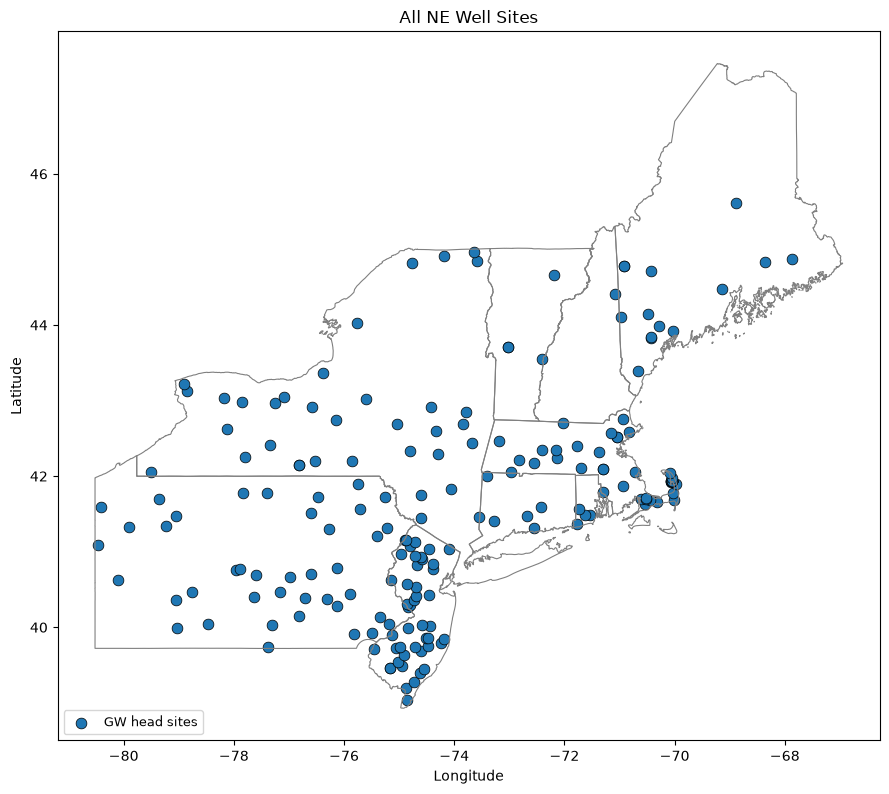

Plotting 7710 NE weather stations


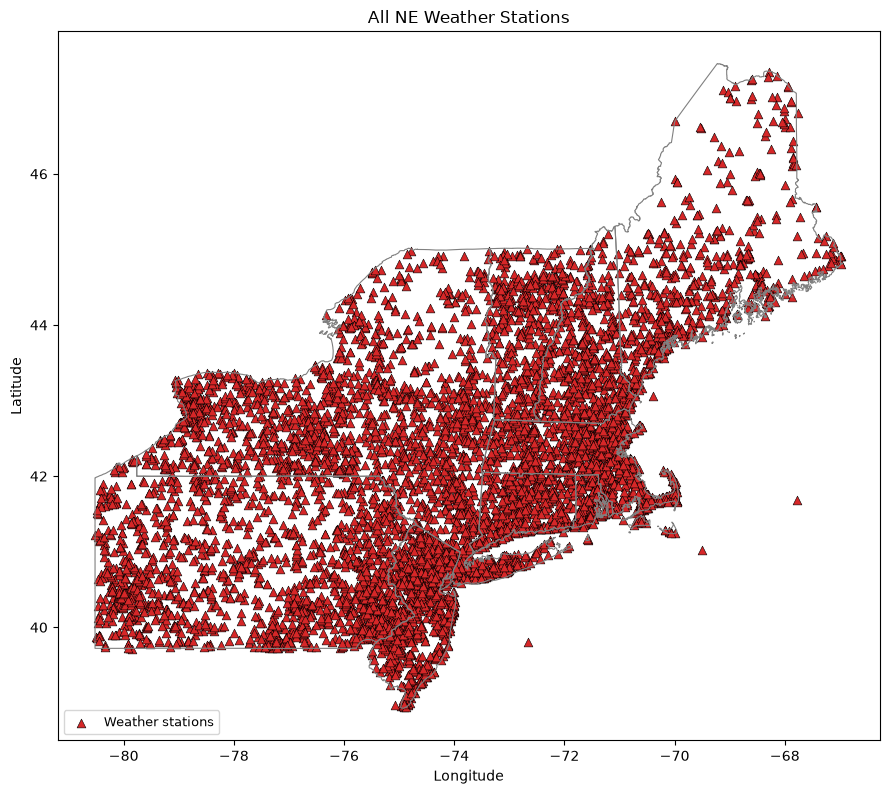

In [24]:
figA = make_ne_sites_map(sites_dist, state_boundaries)
figB = make_ne_stations_map(ne_stations, state_boundaries)

#### Find the closest weather station for each well and discard the other stations. 

NE GW sites: 194
Total NE stations: 7710 -> stations actually used as nearest match: 171


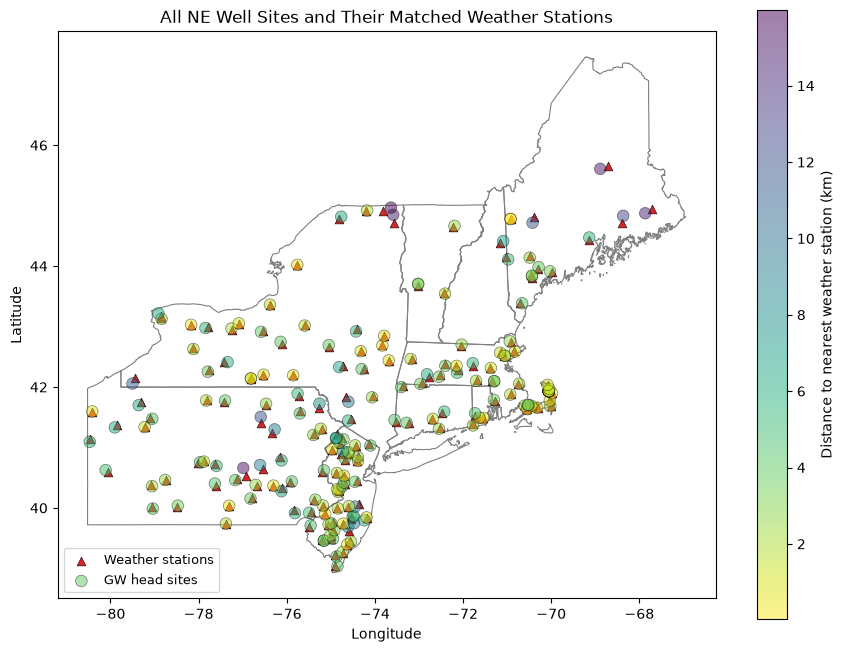

In [26]:
def well_with_station(sites_with_dist, stations, states_shp):
    # only keep stations that are a well's nearest match
    used_station_ids = sites_with_dist["nearest_station_id"].unique()
    used_stations = stations[stations["id"].isin(used_station_ids)]
    print(f"NE GW sites: {len(sites_with_dist)}")
    print(f"Total NE stations: {len(stations)} -> stations actually used as nearest match: {len(used_stations)}")
    states = gpd.read_file(states_shp).set_crs(epsg=4326, allow_override=True)
    ne = states[states["NAME"].isin(NE_states)]
    fig, ax = plt.subplots(figsize=(9, 9))
    ne.boundary.plot(ax=ax, color="gray", linewidth=0.8)
    ax.scatter(
        used_stations["lon"], used_stations["lat"],
        c="tab:red", marker="^", s=40, edgecolor="black", linewidth=0.4,
        label="Weather stations", zorder=2
    )
    scatter = ax.scatter(
        sites_with_dist["lon"], sites_with_dist["lat"],
        c=sites_with_dist["distance_km"], cmap="viridis_r",
        s=70, marker="o", edgecolor="black", linewidth=0.5, zorder=3,
        alpha=0.5,
        label="GW head sites"
    )
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
    cbar.set_label("Distance to nearest weather station (km)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("All NE Well Sites and Their Matched Weather Stations")
    ax.legend(loc="lower left", fontsize=9)
    fig.tight_layout()
    plt.show()
    return fig, used_stations
figC, used_stations = well_with_station(sites_dist, ne_stations, state_boundaries)

#### Filter out well sites that are further than 10km from the nearest weather station. 

In [27]:
def filter_by_distance(sites_dist, max_km=10.0):
    
    n_total = len(sites_dist)
    filtered = sites_dist[sites_dist["distance_km"] <= max_km].copy()
    n_kept = len(filtered)

    print(f"Total NE GW sites: {n_total}")
    print(f"Sites within {max_km} km of a station: {n_kept} "
          f"({n_kept / n_total:.1%})")
    print(f"Dropped: {n_total - n_kept} sites "
          f"({(n_total - n_kept) / n_total:.1%})")

    return filtered.reset_index(drop=True)

sites_filtered = filter_by_distance(sites_dist, max_km=10.0)

Total NE GW sites: 194
Sites within 10.0 km of a station: 185 (95.4%)
Dropped: 9 sites (4.6%)


#### Using the parameters determine in the Henny et al. (2023) paper, mark each precipitaiton day as either extreme or not. 

In [28]:
def label_extreme_precip(precip_df, date_col="date", precip_col="precip_mm"):
    """
    Henny et al. (2023) method
      - Winter (DJF), Spring (MAM), Fall (SON): 99th percentile of
        nonzero precip days, computed per season
      - Summer (JJA): 95th percentile of nonzero precip days
    
    """
    df = precip_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["month"] = df[date_col].dt.month

    season_map = {12: "DJF", 1: "DJF", 2: "DJF",
                  3: "MAM", 4: "MAM", 5: "MAM",
                  6: "JJA", 7: "JJA", 8: "JJA",
                  9: "SON", 10: "SON", 11: "SON"}
    df["season"] = df["month"].map(season_map)

    thresholds = {}
    df["is_extreme"] = False

    for season, group in df.groupby("season"):
        nonzero = group.loc[group[precip_col] > 0, precip_col]
        pctile = 95 if season == "JJA" else 99
        thresh = nonzero.quantile(pctile / 100)
        thresholds[season] = thresh
        mask = (df["season"] == season) & (df[precip_col] >= thresh)
        df.loc[mask, "is_extreme"] = True

    print("Station extreme precip thresholds (mm):")
    for season, thresh in thresholds.items():
        print(f"  {season}: {thresh:.1f} mm ({'95th' if season=='JJA' else '99th'} pctile)")

    return df.drop(columns="month"), thresholds

#### Import the daily precipiation and temperature data from NOAA. 

In [34]:
GHCND_BASE = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/all/{station_id}.dly"


def download_ghcnd_dly(station_id, out_dir="ghcnd_raw"):
    """Downloads the raw .dly file for one station, if not already saved."""
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f"{station_id}.dly")

    if os.path.exists(path):
        return path

    url = GHCND_BASE.format(station_id=station_id)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    with open(path, "w") as f:
        f.write(resp.text)
    return path


def parse_ghcnd_dly(path, elements=("PRCP", "TMAX", "TMIN")):
    """Parses a GHCN-D .dly fixed-width file into a tidy long-format DataFrame."""
    colspecs = [(0, 11), (11, 15), (15, 17), (17, 21)]
    day_start = 21
    for day in range(31):
        colspecs.append((day_start, day_start + 5))
        colspecs.append((day_start + 5, day_start + 6))
        colspecs.append((day_start + 6, day_start + 7))
        colspecs.append((day_start + 7, day_start + 8))
        day_start += 8

    names = ["station_id", "year", "month", "element"]
    for day in range(1, 32):
        names += [f"value{day}", f"mflag{day}", f"qflag{day}", f"sflag{day}"]

    df = pd.read_fwf(path, colspecs=colspecs, names=names, dtype={"element": str})
    df = df[df["element"].isin(elements)]

    records = []
    for _, row in df.iterrows():
        for day in range(1, 32):
            val = row[f"value{day}"]
            if val == -9999:
                continue
            try:
                date = pd.Timestamp(year=int(row["year"]), month=int(row["month"]), day=day)
            except ValueError:
                continue
            records.append({
                "station_id": row["station_id"],
                "date": date,
                "element": row["element"],
                "value": val,
                "qflag": row[f"qflag{day}"],
            })

    out = pd.DataFrame(records)
    out["value"] = out["value"].astype(float)
    out.loc[out["element"] == "PRCP", "value"] = out.loc[out["element"] == "PRCP", "value"] / 10.0
    out.loc[out["element"].isin(["TMAX", "TMIN"]), "value"] = (
        out.loc[out["element"].isin(["TMAX", "TMIN"]), "value"] / 10.0
    )
    return out


def station_data(station_id, elements=("PRCP", "TMAX", "TMIN"),
                  raw_dir="ghcnd_raw", parsed_dir="ghcnd_parsed"):
    """
    Downloads + parses one station's data, with caching at both stages:
      - Skips downloading if the raw .dly file is already saved locally
      - Skips re-parsing if a parsed version is already cached on disk
    """
    os.makedirs(parsed_dir, exist_ok=True)
    elements_key = "_".join(sorted(elements))
    parsed_path = os.path.join(parsed_dir, f"{station_id}_{elements_key}.pkl")

    if os.path.exists(parsed_path):
        with open(parsed_path, "rb") as f:
            return pickle.load(f)

    raw_path = download_ghcnd_dly(station_id, out_dir=raw_dir)
    result = parse_ghcnd_dly(raw_path, elements=elements)

    with open(parsed_path, "wb") as f:
        pickle.dump(result, f)

    return result

#### Clean and load the files from the Henny paper.

In [30]:
groundwater_dir = r"C:\Users\romin\OneDrive\Groundwater"
clim_path = os.path.join(groundwater_dir, "extreme_days_ghcnd_99_80_fall.nc")
ds_clim = xr.open_dataset(clim_path)

def clean_station_name(raw_path):
    return os.path.splitext(os.path.basename(str(raw_path)))[0]

ds_clim['stations'] = xr.apply_ufunc(clean_station_name, ds_clim['stations'], vectorize=True)

unique_stations = pd.unique(ds_clim['stations'].values)
print(f"Total rows (extreme-day events): {len(ds_clim['stations'].values)}")
print(f"Unique stations in this file: {len(unique_stations)}")
print(unique_stations[:20])

Total rows (extreme-day events): 42724
Unique stations in this file: 314
['USC00060299' 'USC00060973' 'USC00065445' 'USC00065910' 'USC00072730'
 'USC00079605' 'USC00170480' 'USC00170814' 'USC00170833' 'USC00171628'
 'USC00171975' 'USC00172765' 'USC00172878' 'USC00173046' 'USC00173261'
 'USC00173567' 'USC00173588' 'USC00174086' 'USC00174927' 'USC00175460']


In [32]:
for root, dirs, files in os.walk(groundwater_dir):
    for f in files:
        if f.endswith(".nc"):
            print(os.path.join(root, f))
def get_clean_name(path):
    # os.path.basename gets 'USC00060299.dly'
    # os.path.splitext splits it into ('USC00060299', '.dly')
    return os.path.splitext(os.path.basename(path))[0]
#File 1
clim_path = os.path.join(groundwater_dir, "extreme_days_ghcnd_99_80_fall.nc")
xr_clim = xr.open_dataset(clim_path)
xr_clim['stations'] = xr.apply_ufunc(get_clean_name, xr_clim['stations'], vectorize=True)
xr_clim = xr_clim.set_coords('stations')

#File 2
class_path = os.path.join(groundwater_dir, "neusa_ep_days_stats_seasonal_ep_days95NEW_fall.nc")
xr_class = xr.open_dataset(class_path)

# File 3
other_path = os.path.join(groundwater_dir, "climo_neusa_ar95constNEW_fall.nc")
xr_other = xr.open_dataset(other_path)

for var in xr_other.data_vars:
    if 'stations' in var:
        print(var)
        xr_other[var] = xr.apply_ufunc(get_clean_name, xr_other[var], vectorize=True)

C:\Users\romin\OneDrive\Groundwater\climo_neusa_ar95constNEW_fall.nc
C:\Users\romin\OneDrive\Groundwater\extreme_days_ghcnd_99_80_fall.nc
C:\Users\romin\OneDrive\Groundwater\neusa_ep_days_stats_seasonal_ep_days95NEW_fall.nc
stations_pure_ar
stations_pure_tc
stations_pure_extreme_ivt
stations_tc_linked_ar
stations_tc_remnant_linked_ar
stations_tc_linked_ivt
stations_tc_remnant_linked_ivt
stations_tc_remnants
stations_tc_ar_combo
stations_tc_remnant_ar_combo
stations_other


#### Compare the stations I found to the ones used in the Henny paper. 

In [31]:
my_station_ids = sites_filtered["nearest_station_id"].unique().tolist()
overlap = set(unique_stations) & set(my_station_ids)

print(f"\nOur filtered sites use {len(my_station_ids)} unique stations.")
print(f"Overlap with Henny's fall extreme-day file: {len(overlap)} stations")
print(overlap)


Our filtered sites use 162 unique stations.
Overlap with Henny's fall extreme-day file: 5 stations
{'USC00281582', 'USC00283029', 'USC00300443', 'USW00093730', 'USC00362470'}


#### Isolating extreme precipitation days for fall. 

In [37]:
test_station = 'USC00283029'
station_df = station_data_int(test_station, elements=("PRCP",))

precip_only = station_df[station_df["element"] == "PRCP"][["date", "value"]]
precip_only = precip_only.rename(columns={"value": "precip_mm"})

labeled, thresholds = label_extreme_precip(precip_only, date_col="date", precip_col="precip_mm")

labeled["month"] = labeled["date"].dt.month
fall_labeled = labeled[labeled["month"].isin([9, 10, 11])]

my_extreme_dates = set(fall_labeled.loc[fall_labeled["is_extreme"], "date"].dt.normalize())
print(f"\nThe method found {len(my_extreme_dates)} fall extreme days")

Station extreme precip thresholds (mm):
  DJF: 45.3 mm (99th pctile)
  JJA: 39.9 mm (95th pctile)
  MAM: 51.7 mm (99th pctile)
  SON: 68.1 mm (99th pctile)

The method found 37 fall extreme days


#### Pull groundwater head data from USGS.

In [38]:
def get_usgs_groundwater(site_id, start_date="2014-01-01", end_date="2024-01-01"):
    """
    Pulls daily mean depth-to-water-level data for one USGS site.
    parameterCd 72019 = depth to water level, feet below land surface
    """
    url = "https://waterservices.usgs.gov/nwis/dv/"
    params = {
        "format": "rdb",
        "sites": site_id,
        "startDT": start_date,
        "endDT": end_date,
        "parameterCd": "72019",
        "siteType": "GW",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()

    lines = resp.text.splitlines()
    data_lines = [l for l in lines if not l.startswith("#")]
    if len(data_lines) < 3:
        print(f"No data returned for site {site_id}")
        return None

    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="\t")
    df = df.drop(index=0)  # units-description row right after the header

    # Find the "mean" column dynamically, since its exact name varies by site
    mean_col = [c for c in df.columns if c.endswith("00003")]
    if not mean_col:
        print(f"No mean column found for site {site_id}. Columns were: {list(df.columns)}")
        return None
    mean_col = mean_col[0]

    out = df[["site_no", "datetime", mean_col]].copy()
    out = out.rename(columns={mean_col: "depth_to_water_ft"})
    out["datetime"] = pd.to_datetime(out["datetime"])
    out["depth_to_water_ft"] = pd.to_numeric(out["depth_to_water_ft"], errors="coerce")

    return out


gw_data = get_usgs_groundwater("402750078452201")
print(gw_data.head())
print(f"\nTotal days: {len(gw_data)}")
print(f"Date range: {gw_data['datetime'].min()} to {gw_data['datetime'].max()}")

           site_no   datetime  depth_to_water_ft
1  402750078452201 2014-01-01               6.43
2  402750078452201 2014-01-02               6.50
3  402750078452201 2014-01-03               6.76
4  402750078452201 2014-01-04               6.85
5  402750078452201 2014-01-05               6.93

Total days: 3633
Date range: 2014-01-01 00:00:00 to 2024-01-01 00:00:00


#### Plot head and precipitation (with extreme events flagged) for well 402750078452201

Station extreme precip thresholds (mm):
  DJF: 45.3 mm (99th pctile)
  JJA: 39.9 mm (95th pctile)
  MAM: 51.7 mm (99th pctile)
  SON: 68.1 mm (99th pctile)


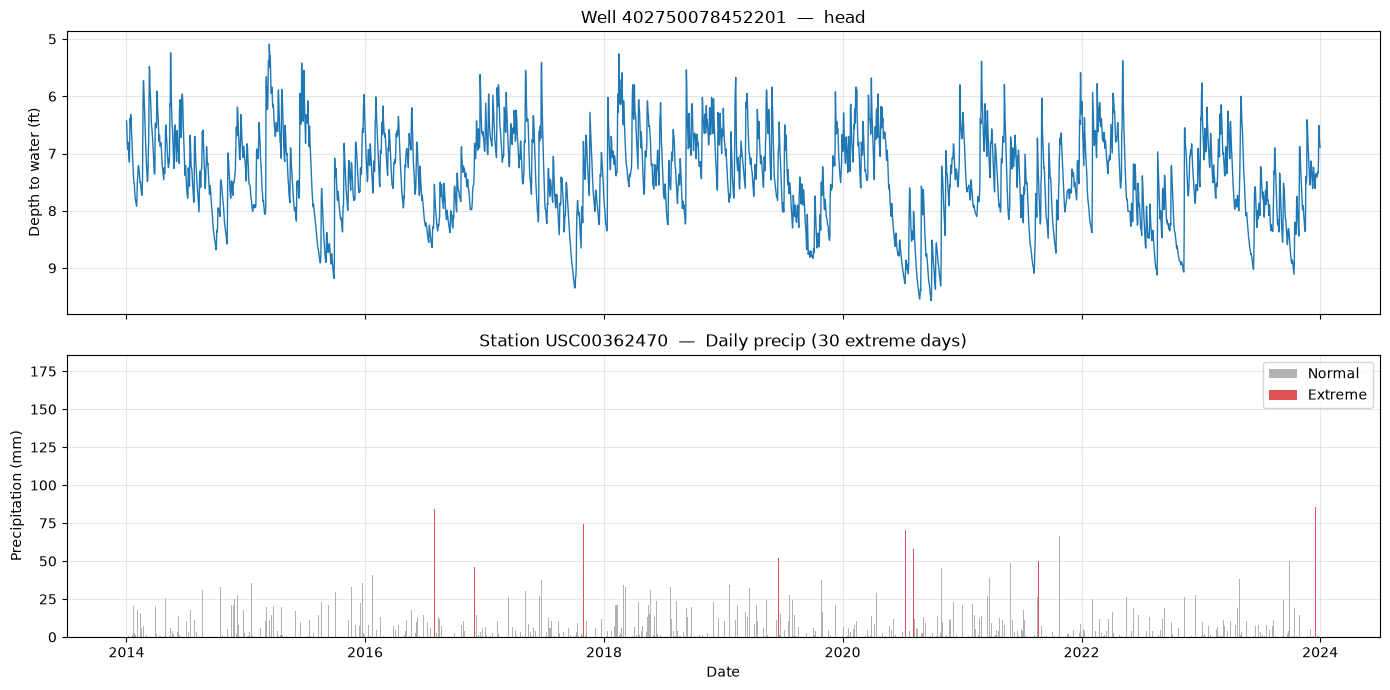

In [44]:
precip_data = station_data("USC00283029", elements=("PRCP",))
precip_data = precip_data[precip_data["element"] == "PRCP"][["date", "value"]].rename(columns={"value": "precip_mm"})

labeled_precip, thresholds = label_extreme_precip(
    precip_data.rename(columns={"datetime": "date"}),
    date_col="date",
    precip_col="precip_mm"
)

merged_labeled = pd.merge(
    gw_data.rename(columns={"datetime": "date"}),
    labeled_precip[["date", "precip_mm", "is_extreme"]],
    on="date",
    how="inner"
)

def plot_site_head_precip_extreme(merged_df, well_id, station_id):
    """
    Two stacked panels sharing the same x-axis:
      - Top: groundwater head
      - Bottom: daily precip, with extreme days colored differently
    """
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 7), sharex=True,
        gridspec_kw={"height_ratios": [1, 1]}
    )

    ax1.plot(merged_df["date"], merged_df["depth_to_water_ft"],
             color="tab:blue", linewidth=1)
    ax1.invert_yaxis()
    ax1.set_ylabel("Depth to water (ft)")
    ax1.set_title(f"Well {well_id}  —  head")
    ax1.grid(alpha=0.3)

    normal_days = merged_df[~merged_df["is_extreme"]]
    extreme_days = merged_df[merged_df["is_extreme"]]

    ax2.bar(normal_days["date"], normal_days["precip_mm"],
            color="tab:gray", alpha=0.6, width=1, label="Normal")
    ax2.bar(extreme_days["date"], extreme_days["precip_mm"],
            color="tab:red", alpha=0.8, width=1, label="Extreme")

    ax2.set_ylabel("Precipitation (mm)")
    ax2.set_xlabel("Date")
    ax2.set_title(f"Station {station_id}  —  Daily precip ({len(extreme_days)} extreme days)")
    ax2.legend(loc="upper right")
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_site_head_precip_extreme(merged_labeled, "402750078452201", "USC00362470")

In [45]:
henny_stations = ['USW00093730', 'USC00300443', 'USC00362470', 'USC00281582', 'USC00283029']
henny_five_wells = sites_filtered[sites_filtered["nearest_station_id"].isin(henny_stations)]
print(henny_five_wells[["usgs_id", "nearest_station_id", "state", "distance_km"]])

             usgs_id nearest_station_id         state  distance_km
7    393232074263903        USW00093730    New Jersey     2.313977
46   402750078452201        USC00362470  Pennsylvania     2.467798
48   403455074514801        USC00283029    New Jersey     1.828594
64   410207074270001        USC00281582    New Jersey     2.172362
162  430146078101301        USC00300443      New York     0.174437


#### Pull and view recharge data? So if this isnt recharge data is it also just change in head data. 

In [46]:
rpsy_dir = r"C:\Users\romin\OneDrive\Groundwater\RpSy Data"
test_file = os.path.join(rpsy_dir, "402750078452201.csv")

recharge_df = pd.read_csv(test_file)

#### Calculate the true recharge value by determining specific yield for each well from the Morris & Johnson (1967) values. 

In [51]:
# Specific yield (Sy) per well, based on Morris & Johnson (1967) values
# for the underlying aquifer material at each well's location.


SY_BY_WELL = {
    "393232074263903": 0.325,   # Cohansey Sand-Kirkwood Fm, unconsolidated sand (~0.32-0.33)
    "402750078452201": 0.165,  # Glenshaw Fm, interbedded sandstone/shale/siltstone/coal
    "403455074514801": 0.27,    # Stockton Fm, arkosic sandstone (medium grained)
    "410207074270001": 0.28,    # Stratified Drift, glacial outwash sand/gravel (~0.24-0.32, midpoint)
    "430146078101301": 0.14,    # Onondaga Limestone, carbonate/karst bedrock
}

print("Specific yield assignments:")
for well_id, sy in SY_BY_WELL.items():
    print(f"  {well_id}: {sy}")

Specific yield assignments:
  393232074263903: 0.325
  402750078452201: 0.165
  403455074514801: 0.27
  410207074270001: 0.28
  430146078101301: 0.14


In [52]:
def add_recharge_columns(df, well_id, rpsy_cols=("total_recharge_m", "peak_recharge_m")):
    """
    Adds true-recharge columns (RpSy x Sy)
    """
    df = df.copy()
    sy = SY_BY_WELL.get(well_id)

    if sy is None:
        print(f"No Sy assigned for well {well_id}. Skipping conversion.")
        return df

    for col in rpsy_cols:
        if col not in df.columns:
            continue

        if isinstance(sy, dict):
            # Range well: produce three separate output columns
            for label, sy_val in sy.items():
                df[f"{col}_recharge_{label}"] = df[col] * sy_val
        else:
            # Single-value well: one output column
            df[f"{col}_recharge"] = df[col] * sy

    return df


def convert_rpsy_series(recharge_df, well_id, rpsy_col="RpSy (m)"):
    """
    Converts a raw daily RpSy time series into
    true recharge.
    """
    df = recharge_df.copy()
    sy = SY_BY_WELL.get(well_id)

    if sy is None:
        print(f"No Sy assigned for well {well_id}. Skipping conversion.")
        return df

    if isinstance(sy, dict):
        for label, sy_val in sy.items():
            df[f"recharge_{label}"] = df[rpsy_col] * sy_val
    else:
        df["recharge"] = df[rpsy_col] * sy

    return df

#### Add true recharge column to the Henny wells.

In [53]:
henny_well_ids = ["393232074263903", "402750078452201", "403455074514801",
                   "410207074270001", "430146078101301"]

recharge_dir = r"C:\Users\romin\OneDrive\Groundwater\RpSy Data"

all_recharge_series = {}

for well_id in henny_well_ids:
    recharge_path = os.path.join(recharge_dir, f"{well_id}.csv")
    if not os.path.exists(recharge_path):
        print(f"No recharge file for {well_id}. Skipping.")
        continue

    recharge_df = pd.read_csv(recharge_path)
    recharge_df["Date"] = pd.to_datetime(recharge_df["Date"])

    converted = convert_rpsy_series(recharge_df, well_id)
    all_recharge_series[well_id] = converted

    print(f"{well_id}: {len(converted)} days loaded, columns: {converted.columns.tolist()}")

print(f"\nTotal wells loaded: {len(all_recharge_series)}")

393232074263903: 5843 days loaded, columns: ['Date', 'RpSy (m)', 'RpSyu (m)', 'recharge']
402750078452201: 5112 days loaded, columns: ['Date', 'RpSy (m)', 'RpSyu (m)', 'recharge']
403455074514801: 10591 days loaded, columns: ['Date', 'RpSy (m)', 'RpSyu (m)', 'recharge']
410207074270001: 9130 days loaded, columns: ['Date', 'RpSy (m)', 'RpSyu (m)', 'recharge']
430146078101301: 2556 days loaded, columns: ['Date', 'RpSy (m)', 'RpSyu (m)', 'recharge']

Total wells loaded: 5


#### Keep wells with >= ten years of recharge data and determine the number of wells with >= five years of precipitation and recharge data. 

In [71]:
def recharge_10(sites_filtered, rpsy_dir, min_years=10):
    """
    Checks each well's recharge CSV in rpsy_dir and keeps only wells
    whose recharge record spans at least 10.
    Wells with no matching recharge file are dropped and reported.
    """
    keep_rows = []
    dropped_no_file = []
    dropped_too_short = []

    for _, row in sites_filtered.iterrows():
        well_id = str(row["usgs_id"])
        file_path = os.path.join(rpsy_dir, f"{well_id}.csv")

        if not os.path.exists(file_path):
            dropped_no_file.append(well_id)
            continue

        df = pd.read_csv(file_path)
        df["Date"] = pd.to_datetime(df["Date"])
        span_years = (df["Date"].max() - df["Date"].min()).days / 365.25

        if span_years >= min_years:
            keep_rows.append(row)
        else:
            dropped_too_short.append((well_id, round(span_years, 1)))

    filtered = pd.DataFrame(keep_rows).reset_index(drop=True)

    print(f"Wells checked: {len(sites_filtered)}")
    print(f"Wells kept (≥{min_years} years of recharge data): {len(filtered)}")
    print(f"Wells dropped — no recharge file found: {len(dropped_no_file)}")
    print(f"Wells dropped — recharge record too short: {len(dropped_too_short)}")

    return filtered, dropped_no_file, dropped_too_short


sites_with_recharge, no_file, too_short = recharge_10(
    sites_filtered, r"C:\Users\romin\OneDrive\Groundwater\RpSy Data", min_years=10
)

Wells checked: 185
Wells kept (≥10 years of recharge data): 126
Wells dropped — no recharge file found: 0
Wells dropped — recharge record too short: 59


In [134]:
def build_overlap_table(sites_filtered, recharge_dir, output_path="overlap_summary.csv"):
    """
    Filters to keep only wells
    with at least 5 years of true overlap.
    """
    if os.path.exists(output_path):
        done = pd.read_csv(output_path)
        done_ids = set(done["usgs_id"].astype(str))
        rows = done.to_dict("records")
        print(f"Resuming — {len(done_ids)} wells already checked.")
    else:
        rows = []
        done_ids = set()

    unique_wells = sites_filtered.drop_duplicates(subset="usgs_id")
    remaining = unique_wells[~unique_wells["usgs_id"].astype(str).isin(done_ids)]
    print(f"{len(remaining)} wells left to check.\n")

    station_cache_local = {}

    for _, row in remaining.iterrows():
        well_id = str(row["usgs_id"])
        station_id = row["nearest_station_id"]

        # Station precip range (cached)
        if station_id not in station_cache_local:
            try:
                precip = station_data_int(station_id, elements=("PRCP",))
                precip = precip[precip["element"] == "PRCP"]
                station_cache_local[station_id] = precip
            except Exception as e:
                print(f"  Error for station {station_id}: {e}")
                station_cache_local[station_id] = pd.DataFrame()

        precip = station_cache_local[station_id]
        if len(precip) == 0:
            rows.append({
                "usgs_id": well_id, "station_id": station_id,
                "overlap_start": None, "overlap_end": None, "overlap_years": 0
            })
            continue
        station_start, station_end = precip["date"].min(), precip["date"].max()

        # Recharge range
        recharge_path = os.path.join(recharge_dir, f"{well_id}.csv")
        if not os.path.exists(recharge_path):
            rows.append({
                "usgs_id": well_id, "station_id": station_id,
                "overlap_start": None, "overlap_end": None, "overlap_years": 0
            })
            continue
        recharge = pd.read_csv(recharge_path)
        recharge["Date"] = pd.to_datetime(recharge["Date"])
        recharge_start, recharge_end = recharge["Date"].min(), recharge["Date"].max()

        # Actual overlap: latest start to earliest end
        overlap_start = max(station_start, recharge_start)
        overlap_end = min(station_end, recharge_end)
        overlap_years = max((overlap_end - overlap_start).days / 365.25, 0)

        rows.append({
            "usgs_id": well_id, "station_id": station_id,
            "overlap_start": overlap_start, "overlap_end": overlap_end,
            "overlap_years": round(overlap_years, 1)
        })

        if len(rows) % 10 == 0:
            pd.DataFrame(rows).to_csv(output_path, index=False)
            print(f"Checked {len(rows)} of {len(unique_wells)} wells...")

    result = pd.DataFrame(rows)
    result.to_csv(output_path, index=False)
    print(f"\nDone. Total checked: {len(result)}")
    return result


overlap_table = build_overlap_table(sites_filtered, r"C:\Users\romin\OneDrive\Groundwater\RpSy Data")

# Filter to wells with at least 5 years of real overlap
wells_5yr_overlap = overlap_table[overlap_table["overlap_years"] >= 5]

print(f"\nTotal wells checked: {len(overlap_table)}")
print(f"Wells with ≥5 years of overlap: {len(wells_5yr_overlap)}")
print(wells_5yr_overlap.sort_values("overlap_years", ascending=False))

185 wells left to check.

Checked 10 of 185 wells...
Checked 20 of 185 wells...
Checked 30 of 185 wells...
Checked 40 of 185 wells...
Checked 50 of 185 wells...
Checked 60 of 185 wells...
Checked 70 of 185 wells...
Checked 80 of 185 wells...
Checked 90 of 185 wells...
Checked 100 of 185 wells...
Checked 110 of 185 wells...
Checked 120 of 185 wells...
  Error for station USR0000MCAP: 'value'
Checked 130 of 185 wells...
Checked 140 of 185 wells...
Checked 150 of 185 wells...
Checked 160 of 185 wells...
Checked 170 of 185 wells...
Checked 180 of 185 wells...

Done. Total checked: 185

Total wells checked: 185
Wells with ≥5 years of overlap: 55
             usgs_id   station_id overlap_start overlap_end  overlap_years
48   403455074514801  USC00283029    1993-10-02  2022-09-30           29.0
39   402207076180801  USC00366126    1989-10-02  2017-09-06           27.9
56   404708076070701  USC00365344    1996-10-02  2022-09-30           26.0
64   410207074270001  USC00281582    1997-10-02  20

#### Visualization of the 55 wells that had >= five years of overlapping recharge and precipiation data. 

Plotting 55 qualifying wells


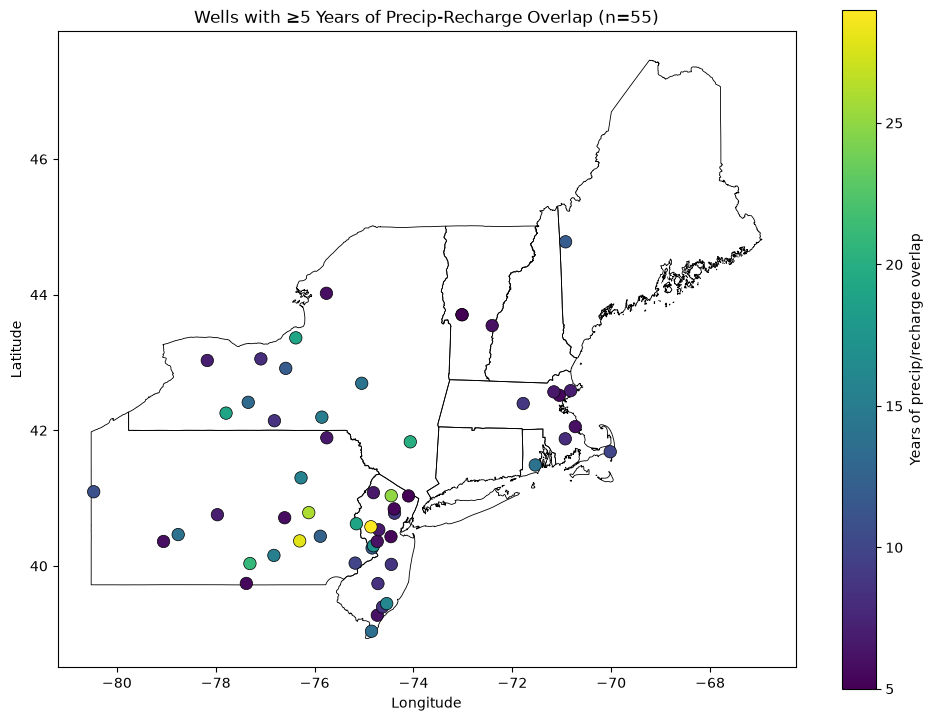

In [136]:
def plot_qualifying_wells_map(wells_5yr_overlap, sites_filtered, states_shp=state_boundaries):
    wells_5yr_overlap = wells_5yr_overlap.copy()
    sites_filtered = sites_filtered.copy()

    wells_5yr_overlap["usgs_id"] = wells_5yr_overlap["usgs_id"].astype(str)
    sites_filtered["usgs_id"] = sites_filtered["usgs_id"].astype(str)

    merged = wells_5yr_overlap.merge(
        sites_filtered[["usgs_id", "lat", "lon", "state"]],
        on="usgs_id", how="left"
    )

    print(f"Plotting {len(merged)} qualifying wells")

    states = gpd.read_file(states_shp)
    ne = states[states["NAME"].isin(NE_states)].copy()
    ne["geometry"] = ne["geometry"].buffer(0)
    ne = ne.set_crs(epsg=4326, allow_override=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    ne.boundary.plot(ax=ax, color="black", linewidth=0.6)

    scatter = ax.scatter(
        merged["lon"], merged["lat"],
        c=merged["overlap_years"], cmap="viridis",
        s=80, edgecolor="black", linewidth=0.5, zorder=3
    )

    cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
    cbar.set_label("Years of precip/recharge overlap")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Wells with ≥5 Years of Precip-Recharge Overlap (n={len(merged)})")
    fig.tight_layout()
    plt.show()

    return merged


qualifying_wells_mapped = plot_qualifying_wells_map(wells_5yr_overlap, sites_filtered)

In [70]:
print(sites_filtered["usgs_id"].dtype)
print(sites_filtered["usgs_id"].head())

# Manually reproduce what the function does, for the first real row
first_row = sites_filtered.iloc[0]
well_id = str(first_row["usgs_id"])
print(f"well_id as string: '{well_id}'")

file_path = os.path.join(recharge_dir, f"{well_id}.csv")
print(f"Constructed path: {file_path}")
print(f"Exists: {os.path.exists(file_path)}")

int64
0    390211074505502
1    391145074520401
2    391621074435401
3    392232074234403
4    392731075092401
Name: usgs_id, dtype: int64
well_id as string: '390211074505502'
Constructed path: C:\Users\romin\OneDrive\Groundwater\RpSy Data\390211074505502.csv
Exists: True


#### Group storm events. This is done by marking any day with precipitation as a storm event and ending it when there is a day with zero precipitation. 

In [54]:
def find_storm_events(precip_df, date_col="date", precip_col="precip_mm"):
    """
    Groups consecutive rainy days (precip > 0) into storm events.
    Any dry day (precip == 0) breaks the event.
    """
    df = precip_df.copy().sort_values(date_col).reset_index(drop=True)
    df["has_rain"] = df[precip_col] > 0

    event_id = 0
    event_ids = []
    prev_rain = False

    for has_rain in df["has_rain"]:
        if has_rain and not prev_rain:
            event_id += 1
        event_ids.append(event_id if has_rain else np.nan)
        prev_rain = has_rain

    df["storm_event_id"] = event_ids

    events = df.dropna(subset=["storm_event_id"]).groupby("storm_event_id").agg(
        start_date=(date_col, "min"),
        end_date=(date_col, "max"),
        total_precip_mm=(precip_col, "sum"),
        max_daily_precip_mm=(precip_col, "max"),
        n_days=(precip_col, "count"),
    ).reset_index()

    return df, events
precip_labeled, storm_events = find_storm_events(precip_data.rename(columns={"datetime": "date"}))


#### Find recharge event using a rise and decline cycles (troughs). 

In [86]:
def recharge_peak(recharge_df, well_id, date_col="Date", recharge_col="RpSy (m)"):
    
    df = recharge_df.copy().sort_values(date_col).reset_index(drop=True)

    sy = SY_BY_WELL.get(well_id)
    if sy is None:
        df["true_recharge_m"] = df[recharge_col]
    elif isinstance(sy, dict):
        df["true_recharge_m"] = df[recharge_col] * sy["sy_mid"]
    else:
        df["true_recharge_m"] = df[recharge_col] * sy

    values = df["true_recharge_m"].values
    peak_indices, _ = find_peaks(-values)
    peak_indices = np.concatenate(([0], peak_indices, [len(values) - 1]))
    peak_indices = np.unique(peak_indices)

    events = []
    for i in range(len(peak_indices) - 1):
        start_idx = peak_indices[i]
        end_idx = peak_indices[i + 1]
        segment = df.loc[start_idx:end_idx]
        if segment["true_recharge_m"].sum() <= 0:
            continue
        peak_idx_within = segment["true_recharge_m"].idxmax()
        events.append({
            "start_date": df.loc[start_idx, date_col],
            "peak_date": df.loc[peak_idx_within, date_col],
            "end_date": df.loc[end_idx, date_col],
            "total_recharge_m": segment["true_recharge_m"].sum(),
            "peak_recharge_m": segment["true_recharge_m"].max(),
            "n_days": end_idx - start_idx + 1,
        })

    return df, pd.DataFrame(events)

#### Finding head and change in head

In [87]:
gw_data = gw_data.rename(columns={"datetime": "date"}) if "datetime" in gw_data.columns else gw_data
gw_data = gw_data.sort_values("date").reset_index(drop=True)
gw_data["head_change_ft"] = -gw_data["depth_to_water_ft"].diff()

Trimming to overlapping range: 2014-01-01 to 2022-09-30


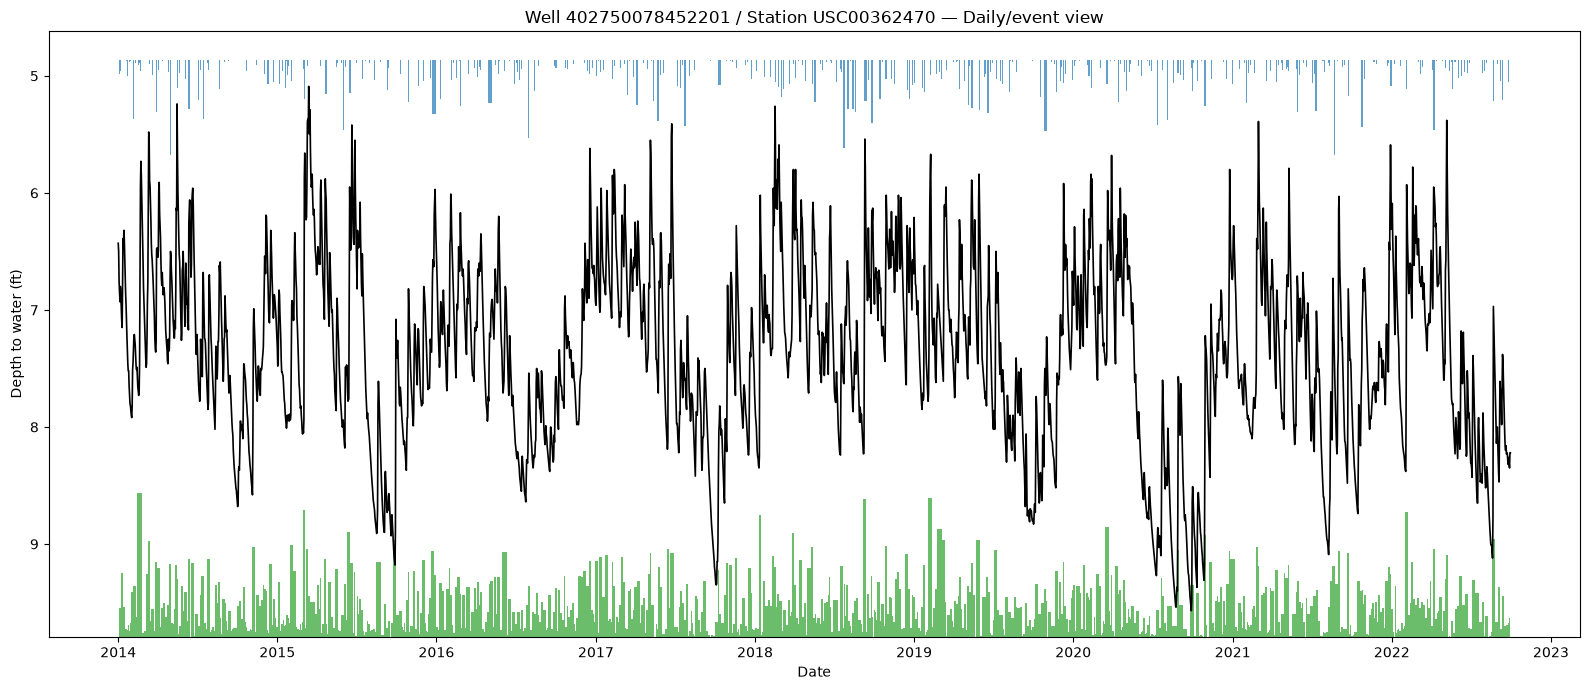

In [97]:
def plot_entire_window(storm_events, recharge_events, gw_data, well_id, station_id):
    """
    Daily/event-based version, automatically trimmed to the date range
    where precip events, recharge events, and head data all overlap.
    """
    storms = storm_events.copy()
    recharges = recharge_events.copy()
    gw = gw_data.copy()

    # Find the overlapping range across all three
    common_start = max(storms["start_date"].min(), recharges["start_date"].min(), gw["date"].min())
    common_end = min(storms["end_date"].max(), recharges["end_date"].max(), gw["date"].max())

    print(f"Trimming to overlapping range: {common_start.date()} to {common_end.date()}")

    storms = storms[(storms["start_date"] >= common_start) & (storms["end_date"] <= common_end)]
    recharges = recharges[(recharges["start_date"] >= common_start) & (recharges["end_date"] <= common_end)]
    gw = gw[(gw["date"] >= common_start) & (gw["date"] <= common_end)]

    fig, ax = plt.subplots(figsize=(16, 7))

    ax.plot(gw["date"], gw["depth_to_water_ft"], color="black", linewidth=1.2, zorder=3)
    ax.invert_yaxis()
    y_min, y_max = ax.get_ylim()
    span = y_max - y_min

    # Precip bars, hanging from the top
    max_precip = storms["total_precip_mm"].max()
    for _, row in storms.iterrows():
        height = (row["total_precip_mm"] / max_precip) * (span * 0.25)
        width_days = max((row["end_date"] - row["start_date"]).days, 1)
        ax.bar(row["start_date"], height, bottom=y_max - height,
               width=width_days, align="edge", color="tab:blue", alpha=0.7, zorder=2)

    # Recharge bars, growing from the bottom
    max_recharge = recharges["total_recharge_m"].max()
    for _, row in recharges.iterrows():
        height = (row["total_recharge_m"] / max_recharge) * (span * 0.25)
        width_days = max((row["end_date"] - row["start_date"]).days, 1)
        ax.bar(row["start_date"], height, bottom=y_min,
               width=width_days, align="edge", color="tab:green", alpha=0.7, zorder=2)

    ax.set_xlabel("Date")
    ax.set_ylabel("Depth to water (ft)")
    ax.set_title(f"Well {well_id} / Station {station_id} — Daily/event view")
    fig.tight_layout()
    plt.show()


recharge_path = os.path.join(recharge_dir, "402750078452201.csv")
recharge_df = pd.read_csv(recharge_path)
recharge_df["Date"] = pd.to_datetime(recharge_df["Date"])

recharge_labeled, recharge_events = recharge_peak(recharge_df, well_id="402750078452201")

plot_entire_window(storm_events, recharge_events, gw_data,
                    well_id="402750078452201", station_id="USC00362470")

#### Creating an event table that connects a storm to a recharge event even if there is still an ongoing recharge event occuring. 

In [98]:
def event_table(precip_df, recharge_df, well_id, station_id,
                 precip_date_col="date", precip_col="precip_mm",
                 recharge_col="RpSy (m)", max_lag_days=30):

    print(f"Well: {well_id}  |  Station: {station_id}\n")

    _, storm_events = find_storm_events(precip_df, date_col=precip_date_col, precip_col=precip_col)
    _, recharge_events = recharge_peak(recharge_df, well_id, date_col="Date", recharge_col=recharge_col)

    print(f"Total storms: {len(storm_events)}")
    print(f"Total recharge events: {len(recharge_events)}")

    rows = []
    for _, storm in storm_events.iterrows():
        storm_end = storm["end_date"]
        candidates = recharge_events[
            (recharge_events["end_date"] >= storm_end) &
            (recharge_events["start_date"] <= storm_end + pd.Timedelta(days=max_lag_days))
        ].copy()
        candidates["lag_days"] = (candidates["start_date"] - storm_end).dt.days
        candidates = candidates.sort_values("lag_days")

        if len(candidates) > 0:
            match = candidates.iloc[0]
            rows.append({
                "precip_start": storm["start_date"], "precip_end": storm["end_date"],
                "total_precip_mm": storm["total_precip_mm"],
                "recharge_start": match["start_date"], "recharge_end": match["end_date"],
                "total_recharge_m": match["total_recharge_m"], "lag_days": match["lag_days"],
            })
        else:
            rows.append({
                "precip_start": storm["start_date"], "precip_end": storm["end_date"],
                "total_precip_mm": storm["total_precip_mm"],
                "recharge_start": None, "recharge_end": None,
                "total_recharge_m": None, "lag_days": None,
            })

    table = pd.DataFrame(rows)
    matched = table["total_recharge_m"].notna().sum()
    print(f"\nFinal table: {len(table)} storms total, {matched} matched to a recharge event "
          f"({matched/len(table):.1%})")
    return table

In [99]:
event_table_test = event_table(
    precip_data, recharge_df,
    well_id="402750078452201", station_id="USC00362470"
)
print(event_table_test.head(15))

Well: 402750078452201  |  Station: USC00362470

Total storms: 8452
Total recharge events: 1259

Final table: 8452 storms total, 971 matched to a recharge event (11.5%)
   precip_start precip_end  total_precip_mm recharge_start recharge_end  \
0    1898-03-02 1898-03-05              5.2            NaT          NaT   
1    1898-03-12 1898-03-13              1.8            NaT          NaT   
2    1898-03-17 1898-03-17              3.8            NaT          NaT   
3    1898-03-20 1898-03-24             40.4            NaT          NaT   
4    1898-03-27 1898-03-31             25.4            NaT          NaT   
5    1898-04-05 1898-04-06             10.5            NaT          NaT   
6    1898-04-10 1898-04-10              1.3            NaT          NaT   
7    1898-04-15 1898-04-16             16.5            NaT          NaT   
8    1898-04-19 1898-04-20              6.3            NaT          NaT   
9    1898-04-24 1898-04-26             37.3            NaT          NaT   
10   18

#### Create a function to bundle the information needed from each well. 

In [109]:
def load_well(well_id, station_id, recharge_dir):

    # Precip
    precip = station_data(station_id, elements=("PRCP",))
    precip = precip[precip["element"] == "PRCP"][["date", "value"]].rename(columns={"value": "precip_mm"})

    # Storms
    _, storms = find_storm_events(precip, date_col="date", precip_col="precip_mm")

    # Recharge (raw)
    recharge_path = os.path.join(recharge_dir, f"{well_id}.csv")
    recharge = pd.read_csv(recharge_path)
    recharge["Date"] = pd.to_datetime(recharge["Date"])

    # Recharge events (trough-based, true recharge via Sy)
    _, recharge_events = recharge_peak(recharge, well_id=well_id)

    # Head data (full range, matching recharge coverage)
    head = get_usgs_groundwater(
        well_id,
        start_date=recharge["Date"].min().strftime("%Y-%m-%d"),
        end_date="2024-01-01"
    )
    head = head.rename(columns={"datetime": "date"}) if head is not None and not head.empty else None

    return {
        "well_id": well_id,
        "station_id": station_id,
        "precip": precip,
        "storms": storms,
        "recharge": recharge,
        "recharge_events": recharge_events,
        "head": head,
    }

#### Determine the average lag between a precipitation event and a recharge event for a well. 

In [100]:
def find_lag(precip_df, recharge_df, well_id, precip_col="precip_mm", recharge_col="RpSy (m)", max_lag=30):
    precip = precip_df.copy()
    recharge = recharge_df.copy()
    precip["date"] = pd.to_datetime(precip["date"])
    recharge["Date"] = pd.to_datetime(recharge["Date"])

    sy = SY_BY_WELL.get(well_id)
    if sy is not None:
        sy_val = sy["sy_mid"] if isinstance(sy, dict) else sy
        recharge["true_recharge"] = recharge[recharge_col] * sy_val
        recharge_col_to_use = "true_recharge"
    else:
        recharge_col_to_use = recharge_col

    precip_daily = precip.set_index("date")[precip_col].asfreq("D", fill_value=0)
    recharge_daily = recharge.set_index("Date")[recharge_col_to_use].asfreq("D", fill_value=0)

    common_start = max(precip_daily.index.min(), recharge_daily.index.min())
    common_end = min(precip_daily.index.max(), recharge_daily.index.max())
    precip_daily = precip_daily[common_start:common_end]
    recharge_daily = recharge_daily[common_start:common_end]

    results = []
    for lag in range(0, max_lag + 1):
        shifted_recharge = recharge_daily.shift(-lag)
        corr = precip_daily.corr(shifted_recharge)
        results.append({"lag_days": lag, "correlation": corr})

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df["correlation"].idxmax()]
    print(f"Best correlation: {best['correlation']:.3f} at lag = {int(best['lag_days'])} days")
    return results_df, int(best["lag_days"])

In [101]:
lag_results, best_lag = find_lag(precip_data, recharge_df, well_id="402750078452201")

Best correlation: 0.317 at lag = 0 days


#### Connect a recharge event to a storm event by looking back in time for the preceeding precipiation event.

In [102]:
def find_preceding_storm(recharge_event_row, storm_events, lookback_days=4):
    """
    Given a recharge event find the most
    recent storm event that occurred in the days before it.
    """
    recharge_start = recharge_event_row["start_date"]

    candidates = storm_events[
        (storm_events["end_date"] <= recharge_start) &
        (storm_events["end_date"] >= recharge_start - pd.Timedelta(days=lookback_days))
    ].copy()

    if len(candidates) == 0:
        return None

    # The most recent one, closest storm end date to the recharge start
    candidates = candidates.sort_values("end_date", ascending=False)
    return candidates.iloc[0]

In [103]:
# Pick the largest
one_recharge_event = recharge_events.loc[recharge_events["total_recharge_m"].idxmax()]

matched_storm = find_preceding_storm(one_recharge_event, storm_events, lookback_days=4)

print("Recharge event:")
print(one_recharge_event)
print("\nMatched preceding storm:")
print(matched_storm)

Recharge event:
start_date          2010-03-04 00:00:00
peak_date           2010-03-12 00:00:00
end_date            2010-03-15 00:00:00
total_recharge_m               0.223194
peak_recharge_m                0.050361
n_days                               12
Name: 120, dtype: object

Matched preceding storm:
storm_event_id                      7353.0
start_date             2010-03-03 00:00:00
end_date               2010-03-03 00:00:00
total_precip_mm                        2.0
max_daily_precip_mm                    2.0
n_days                                   1
Name: 7352, dtype: object


#### Create a function to plot the storm event with its matching precipitation event. 

In [112]:
def plot_storm_to_recharge(matched_storm, recharge_event_row, well, recharge_value_col="total_recharge_m"):
    if matched_storm is None:
        print(f"No matching storm found for recharge event starting "
              f"{recharge_event_row['start_date'].date()}. Skipping plot.")
        return

    precip_df = well["precip"]
    recharge_df = well["recharge"]
    gw_df = well["head"]
    well_id = well["well_id"]

    print("Storm event:")
    print(matched_storm)
    print("\nRecharge event:")
    print(recharge_event_row)
    print()

    window_start = matched_storm["start_date"]
    window_end = recharge_event_row["end_date"]

    precip = precip_df[
        (precip_df["date"] >= matched_storm["start_date"]) &
        (precip_df["date"] <= matched_storm["end_date"])
    ]

    recharge = recharge_df[
        (recharge_df["Date"] >= recharge_event_row["start_date"]) &
        (recharge_df["Date"] <= recharge_event_row["end_date"])
    ].copy()

    # Use true recharge for the bars, converting on the fly
    sy = SY_BY_WELL.get(well_id)
    if sy is not None:
        sy_val = sy["sy_mid"] if isinstance(sy, dict) else sy
        recharge["true_recharge_m"] = recharge["RpSy (m)"] * sy_val
    else:
        recharge["true_recharge_m"] = recharge["RpSy (m)"]

    gw = gw_df[(gw_df["date"] >= window_start) & (gw_df["date"] <= window_end)] if gw_df is not None else None

    fig, ax = plt.subplots(figsize=(9, 6))
    has_head = gw is not None and len(gw) > 0

    if has_head:
        ax.plot(gw["date"], gw["depth_to_water_ft"], color="black", linewidth=1.8, zorder=3, label="Head")
        ax.invert_yaxis()
        y_min, y_max = ax.get_ylim()
    else:
        y_min, y_max = 0, 1
        ax.set_ylim(y_min, y_max)

    span = y_max - y_min

    if len(precip) > 0 and precip["precip_mm"].max() > 0:
        heights_p = (precip["precip_mm"] / precip["precip_mm"].max()) * (span * 0.25)
        ax.bar(precip["date"], heights_p, bottom=y_max - heights_p,
               width=0.8, color="tab:blue", alpha=0.7, zorder=2, label="Precip (storm)")

    if len(recharge) > 0 and recharge["true_recharge_m"].max() > 0:
        heights_r = (recharge["true_recharge_m"] / recharge["true_recharge_m"].max()) * (span * 0.25)
        ax.bar(recharge["Date"], heights_r, bottom=y_min,
               width=0.8, color="tab:green", alpha=0.7, zorder=2, label="True Recharge")

    ax.set_xlim(window_start - pd.Timedelta(hours=12), window_end + pd.Timedelta(hours=12))
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_title(f"Well {well_id}\nStorm: {matched_storm['start_date'].date()} to {matched_storm['end_date'].date()} "
                 f"({matched_storm['total_precip_mm']:.1f} mm)\n"
                 f"Recharge: {recharge_event_row['start_date'].date()} to {recharge_event_row['end_date'].date()} "
                 f"({recharge_event_row[recharge_value_col]:.3f} m)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Depth to water (ft)" if has_head else "")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()

In [113]:
_, recharge_events_cycle = recharge_peak(recharge_df, well_id="402750078452201")
print(f"Recharge events found: {len(recharge_events_cycle)}")

one_recharge_event = recharge_events_cycle[recharge_events_cycle["n_days"] <= 20].sort_values(
    "total_recharge_m", ascending=False
).iloc[0]
print(one_recharge_event)

matched_storm = find_preceding_storm(one_recharge_event, storm_events, lookback_days=4)
print("\nMatched storm:")
print(matched_storm)

Recharge events found: 1259
start_date          2010-03-04 00:00:00
peak_date           2010-03-12 00:00:00
end_date            2010-03-15 00:00:00
total_recharge_m               0.223194
peak_recharge_m                0.050361
n_days                               12
Name: 120, dtype: object

Matched storm:
storm_event_id                      7353.0
start_date             2010-03-03 00:00:00
end_date               2010-03-03 00:00:00
total_precip_mm                        2.0
max_daily_precip_mm                    2.0
n_days                                   1
Name: 7352, dtype: object


Storm event:
storm_event_id                      3212.0
start_date             2010-03-03 00:00:00
end_date               2010-03-03 00:00:00
total_precip_mm                        2.5
max_daily_precip_mm                    2.5
n_days                                   1
Name: 3211, dtype: object

Recharge event:
start_date          2010-03-04 00:00:00
peak_date           2010-03-12 00:00:00
end_date            2010-03-15 00:00:00
total_recharge_m               0.223194
peak_recharge_m                0.050361
n_days                               12
Name: 120, dtype: object



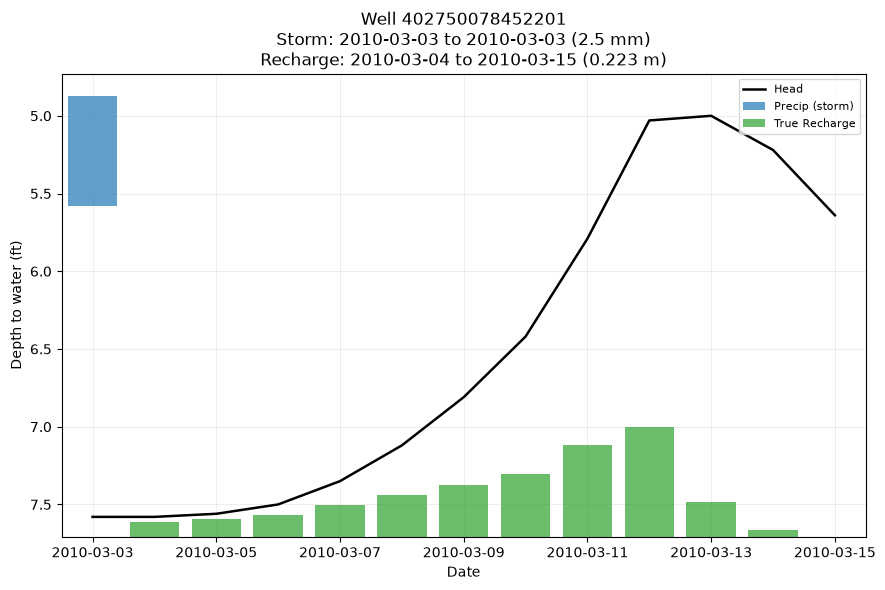

In [116]:
well = load_well("402750078452201", "USC00362470", recharge_dir)
Station_ids = set(sites_filtered["nearest_station_id"].unique())
# Everything is right there:
one_recharge_event = well["recharge_events"][well["recharge_events"]["n_days"] <= 20].sort_values(
    "total_recharge_m", ascending=False
).iloc[0]

matched_storm = find_preceding_storm(one_recharge_event, well["storms"], lookback_days=4)

plot_storm_to_recharge(matched_storm, one_recharge_event, well)

#### Create a table for the full timeline of a given well. 

In [167]:
def full_table(precip_df, recharge_df, well_id, station_id,
                                precip_col="precip_mm", recharge_col="RpSy (m)",
                                lookback_days=10):
    """
    Full-record storm-to-recharge matching:
      1. Detects recharge events as trough-to-trough cycles (true recharge, via Sy)
      2. For each recharge event, looks BACKWARD up to lookback_days
         to find its triggering storm
      3. Returns one row per recharge event, with its matched storm
         (or blank fields if no storm was found in range)
    """
    precip = precip_df.copy()
    precip["date"] = pd.to_datetime(precip["date"])
    recharge = recharge_df.copy()
    recharge["Date"] = pd.to_datetime(recharge["Date"])

    print(f"Well: {well_id}  |  Station: {station_id}\n")

    _, storm_events = find_storm_events(precip, date_col="date", precip_col=precip_col)
    _, recharge_events = recharge_peak(recharge, well_id, date_col="Date", recharge_col=recharge_col)

    print(f"Recharge events (trough-based, true recharge): {len(recharge_events)} total")

    rows = []
    for _, rech in recharge_events.iterrows():
        matched_storm = find_preceding_storm(rech, storm_events, lookback_days=lookback_days)
        if matched_storm is not None:
            rows.append({
                "precip_start": matched_storm["start_date"],
                "precip_end": matched_storm["end_date"],
                "total_precip_mm": matched_storm["total_precip_mm"],
                "recharge_start": rech["start_date"],
                "recharge_peaks": rech["peak_date"],
                "recharge_end": rech["end_date"],
                "total_recharge_m": rech["total_recharge_m"],
                "lag_days": (matched_storm["end_date"] - rech["start_date"]).days * -1,
            })
        else:
            rows.append({
                "precip_start": None, "precip_end": None, "total_precip_mm": None,
                "recharge_start": rech["start_date"], "recharge_peaks": rech["peak_date"],
                "recharge_end": rech["end_date"], "total_recharge_m": rech["total_recharge_m"],
                "lag_days": None,
            })

    table = pd.DataFrame(rows)
    matched = table["total_precip_mm"].notna().sum()
    print(f"Matched to a preceding storm: {matched} of {len(table)} "
          f"({matched/len(table):.1%})")
    return table

In [168]:
full_matched_table = full_table(well["precip"], well["recharge"], well["well_id"], well["station_id"])
print(full_matched_table.head(10))

Well: 402750078452201  |  Station: USC00362470

Recharge events (trough-based, true recharge): 1259 total
Matched to a preceding storm: 1241 of 1259 (98.6%)
  precip_start precip_end  total_precip_mm recharge_start recharge_peaks  \
0          NaT        NaT              NaN     2008-10-02     2008-10-02   
1          NaT        NaT              NaN     2008-10-03     2008-10-05   
2   2008-09-26 2008-10-05             34.8     2008-10-06     2008-10-09   
3   2008-10-09 2008-10-09              4.1     2008-10-12     2008-10-17   
4   2008-10-16 2008-10-18              6.6     2008-10-20     2008-10-26   
5   2008-10-25 2008-10-26             23.7     2008-10-27     2008-10-31   
6   2008-10-28 2008-10-30             19.6     2008-11-04     2008-11-07   
7   2008-11-08 2008-11-10              2.4     2008-11-10     2008-11-16   
8   2008-11-08 2008-11-10              2.4     2008-11-20     2008-11-25   
9   2008-11-25 2008-11-27             31.1     2008-11-29     2008-12-01   

  rech

#### Create a visualization of the full table. 

In [169]:
def complete_timeseries(matched_table, well):
    gw_df = well["head"]
    well_id = well["well_id"]
    station_id = well["station_id"]

    table = matched_table.dropna(subset=["precip_start"]).copy()
    has_head = gw_df is not None and len(gw_df) > 0

    common_start = max(
        table["precip_start"].min(),
        table["recharge_start"].min(),
        gw_df["date"].min() if has_head else table["precip_start"].min()
    )
    common_end = min(
        table["precip_end"].max(),
        table["recharge_end"].max(),
        gw_df["date"].max() if has_head else table["precip_end"].max()
    )
    print(f"Overlapping range: {common_start.date()} to {common_end.date()}")

    table = table[(table["precip_start"] >= common_start) & (table["recharge_end"] <= common_end)]
    if has_head:
        gw_df = gw_df[(gw_df["date"] >= common_start) & (gw_df["date"] <= common_end)]

    table.to_csv(f"{well_id}_{station_id}_complete_timeseries.csv", index=False)

    fig, ax = plt.subplots(figsize=(18, 8))

    if has_head:
        ax.plot(gw_df["date"], gw_df["depth_to_water_ft"], color="black", linewidth=1.0, zorder=3, label="Head")
        ax.invert_yaxis()
        y_min, y_max = ax.get_ylim()
    else:
        y_min, y_max = 0, 1
        ax.set_ylim(y_min, y_max)

    span = y_max - y_min

    max_precip = table["total_precip_mm"].max()
    for _, row in table.iterrows():
        height = (row["total_precip_mm"] / max_precip) * (span * 0.25)
        width_days = max((row["precip_end"] - row["precip_start"]).days, 1)
        ax.bar(row["precip_start"], height, bottom=y_max - height,
               width=width_days, align="edge", color="tab:blue", alpha=0.6, zorder=2)

    max_recharge = table["total_recharge_m"].max()
    for _, row in table.iterrows():
        height = (row["total_recharge_m"] / max_recharge) * (span * 0.25)
        width_days = max((row["recharge_end"] - row["recharge_start"]).days, 1)
        ax.bar(row["recharge_start"], height, bottom=y_min,
               width=width_days, align="edge", color="tab:green", alpha=0.6, zorder=2)

    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.text(0.01, 0.97, "P", transform=ax.transAxes, color="tab:blue", fontsize=13, fontweight="bold", va="top")
    ax.text(0.01, 0.5, "H", transform=ax.transAxes, color="black", fontsize=13, fontweight="bold", va="center")
    ax.text(0.01, 0.03, "R", transform=ax.transAxes, color="tab:green", fontsize=13, fontweight="bold", va="bottom")

    ax.set_xlabel("Date")
    ax.set_ylabel("Depth to water (ft)" if has_head else "")
    ax.set_title(f"Well {well_id} / Station {station_id}\n"
                 f"{len(table)} matched storm-recharge pairs (true recharge)")
    fig.tight_layout()
    fig.savefig(f"{well_id}_{station_id}_complete_timeseries.png", dpi=300)
    plt.show()

GW days: 5539
           site_no       date  depth_to_water_ft
1  402750078452201 2008-10-02               8.88
2  402750078452201 2008-10-03               8.90
3  402750078452201 2008-10-04               8.91
4  402750078452201 2008-10-05               8.84
5  402750078452201 2008-10-06               8.92
Overlapping range: 2008-10-06 to 2022-09-26


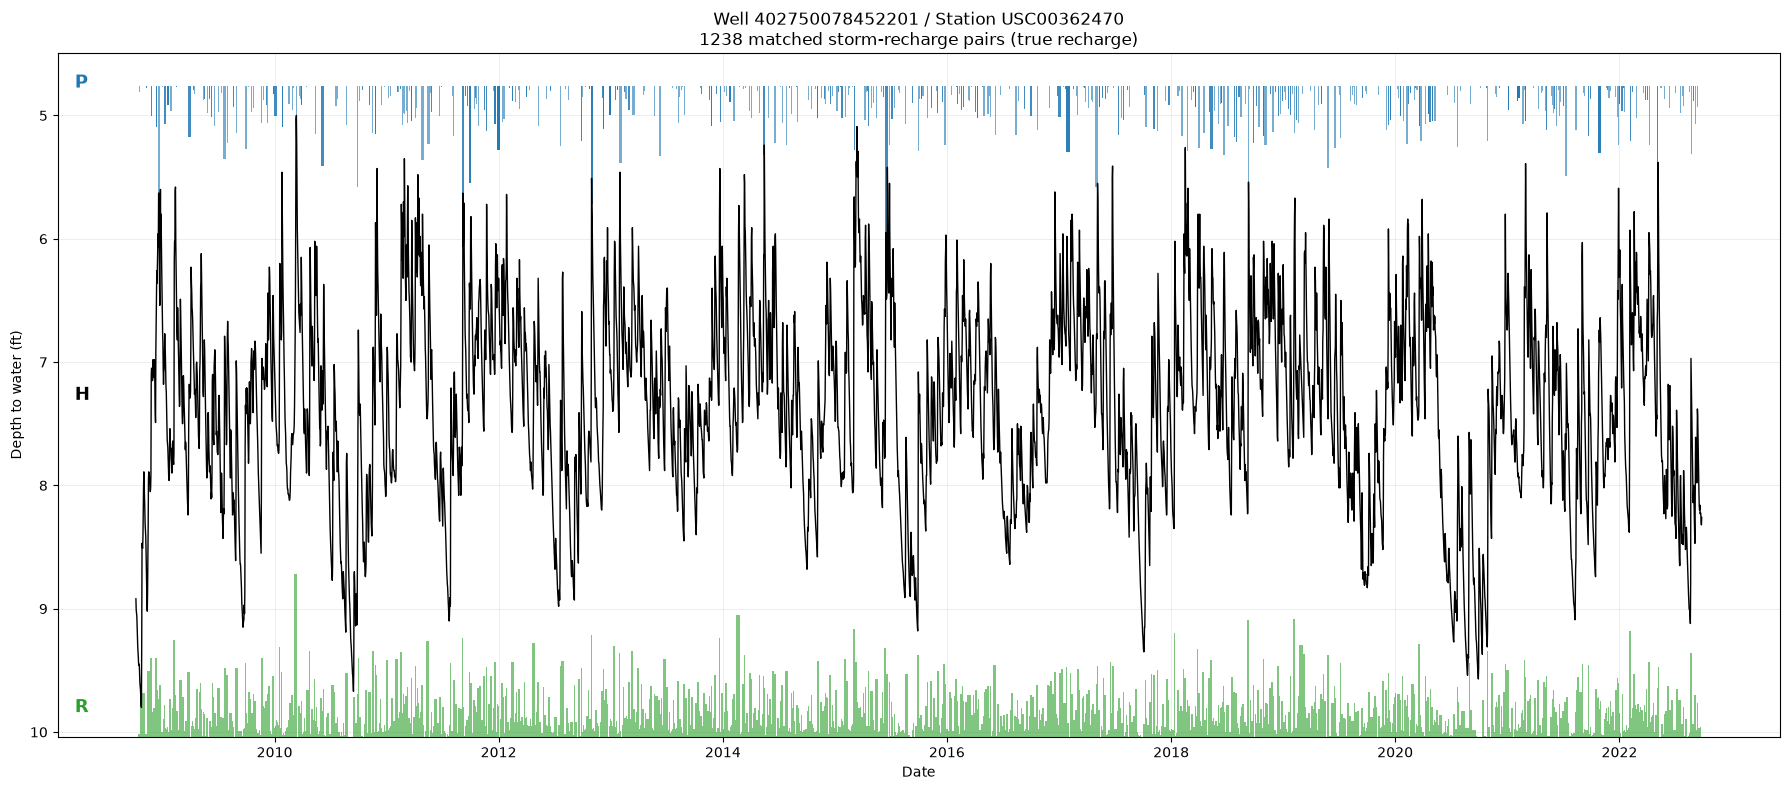

In [170]:
gw = get_usgs_groundwater(
    "402750078452201",
    start_date=recharge_df["Date"].min().strftime("%Y-%m-%d"),
    end_date="2024-01-01"
)
gw = gw.rename(columns={"datetime": "date"})

print(f"GW days: {len(gw)}")
print(gw.head())
complete_timeseries(full_matched_table, well)

In [171]:
def timeseries_stacked(matched_table, well, top_n=5):
    gw_df = well["head"]
    well_id = well["well_id"]
    station_id = well["station_id"]

    table = matched_table.dropna(subset=["precip_start"]).copy()
    has_head = gw_df is not None and len(gw_df) > 0

    common_start = max(
        table["precip_start"].min(), table["recharge_start"].min(),
        gw_df["date"].min() if has_head else table["precip_start"].min()
    )
    common_end = min(
        table["precip_end"].max(), table["recharge_end"].max(),
        gw_df["date"].max() if has_head else table["precip_end"].max()
    )
    print(f"Trimming to overlapping range: {common_start.date()} to {common_end.date()}")

    table = table[(table["precip_start"] >= common_start) & (table["recharge_end"] <= common_end)]
    if has_head:
        gw_df = gw_df[(gw_df["date"] >= common_start) & (gw_df["date"] <= common_end)]

    top_events = table.sort_values("total_recharge_m", ascending=False).head(top_n)
    print(f"\nTop {top_n} recharge events and their matched precipitation events:")
    print(top_events[["precip_start", "precip_end", "total_precip_mm",
                        "recharge_start", "recharge_end", "total_recharge_m", "lag_days"]])

    fig, (ax_p, ax_h, ax_r) = plt.subplots(
        3, 1, figsize=(18, 9), sharex=True,
        gridspec_kw={"height_ratios": [1, 1.5, 1], "hspace": 0}
    )

    for _, row in table.iterrows():
        width_days = max((row["precip_end"] - row["precip_start"]).days, 1)
        ax_p.bar(row["precip_start"], row["total_precip_mm"], width=width_days,
                  align="edge", color="tab:blue", alpha=0.7)
    ax_p.set_ylabel("Precip (mm)", color="tab:blue")
    ax_p.tick_params(axis="y", labelcolor="tab:blue")
    ax_p.grid(True, alpha=0.3, linewidth=0.5)

    if has_head:
        ax_h.plot(gw_df["date"], gw_df["depth_to_water_ft"], color="black", linewidth=1.0)
        ax_h.invert_yaxis()
    ax_h.set_ylabel("Depth to water (ft)")
    ax_h.grid(True, alpha=0.3, linewidth=0.5)

    for _, row in table.iterrows():
        width_days = max((row["recharge_end"] - row["recharge_start"]).days, 1)
        ax_r.bar(row["recharge_start"], row["total_recharge_m"], width=width_days,
                  align="edge", color="tab:green", alpha=0.7)
    ax_r.set_ylabel("True Recharge (m)", color="tab:green")
    ax_r.tick_params(axis="y", labelcolor="tab:green")
    ax_r.grid(True, alpha=0.3, linewidth=0.5)
    ax_r.set_xlabel("Date")

    for _, row in top_events.iterrows():
        for ax in (ax_p, ax_h, ax_r):
            ax.axvline(row["recharge_start"], color="red", linewidth=1.5, alpha=0.3, zorder=5)

    fig.suptitle(f"Well {well_id} / Station {station_id} — {len(table)} matched storm-recharge pairs\n"
                 f"Red lines mark top {top_n} recharge events (true recharge)", y=0.95)
    fig.savefig(f"{well_id}_{station_id}_stacked_timeseries.png", dpi=300)
    plt.show()

Trimming to overlapping range: 2008-10-06 to 2022-09-26

Top 5 recharge events and their matched precipitation events:
    precip_start precip_end  total_precip_mm recharge_start recharge_end  \
120   2010-03-03 2010-03-03              2.5     2010-03-04   2010-03-15   
475   2014-02-10 2014-02-11              6.9     2014-02-14   2014-02-25   
936   2019-01-29 2019-02-02              8.9     2019-02-02   2019-02-10   
896   2018-09-05 2018-09-05              1.5     2018-09-06   2018-09-12   
577   2015-03-01 2015-03-02             17.8     2015-03-02   2015-03-06   

     total_recharge_m  lag_days  
120          0.223194       1.0  
475          0.167841       3.0  
936          0.162171       0.0  
896          0.160972       1.0  
577          0.147837       0.0  


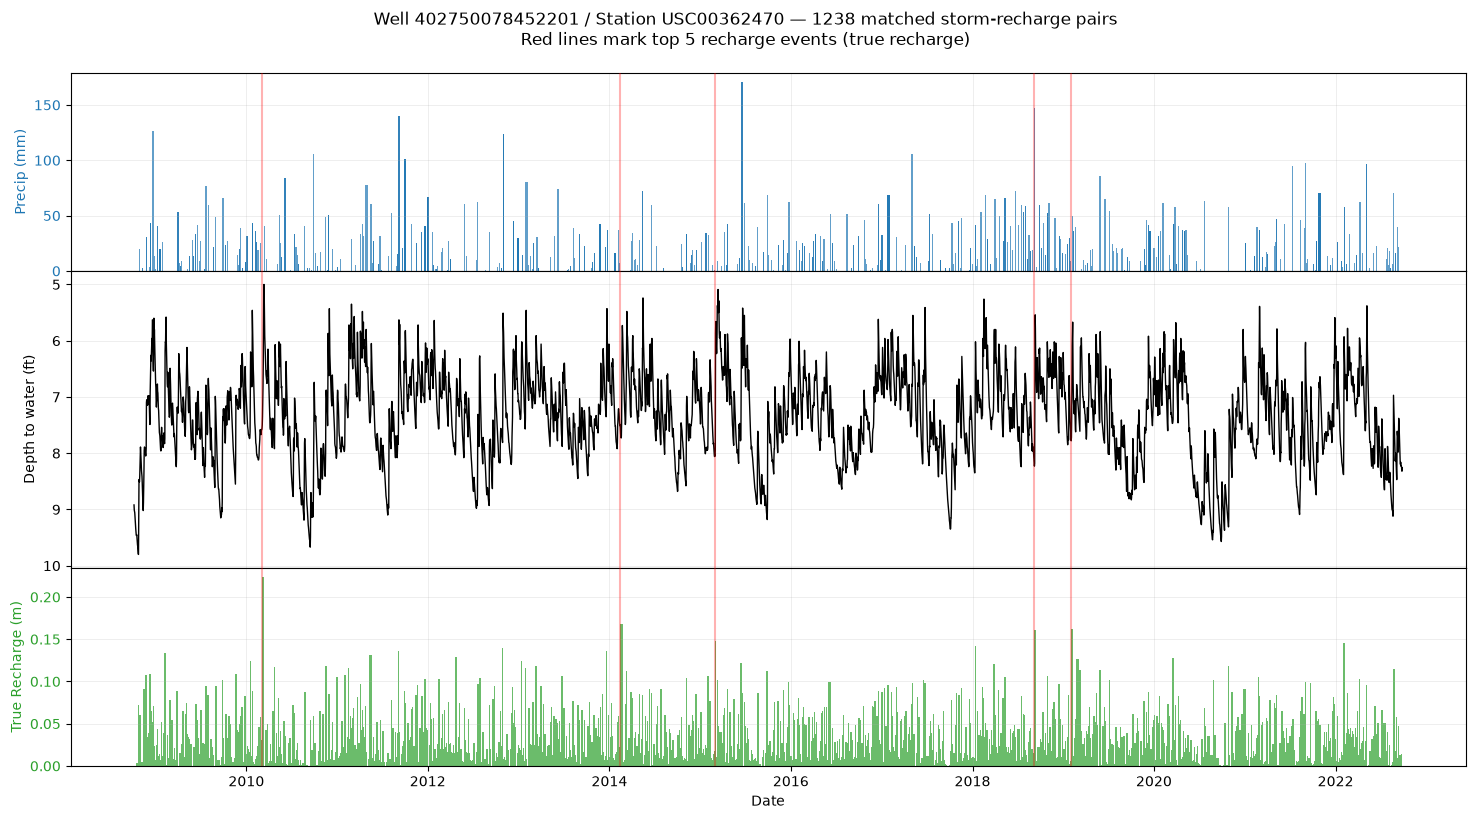

In [172]:
timeseries_stacked(full_matched_table, well)

#### Repeat the process for the remaining four wells. 

WELL 393232074263903  /  STATION USW00093730
Well: 393232074263903  |  Station: USW00093730

Recharge events (trough-based, true recharge): 1469 total
Matched to a preceding storm: 1424 of 1469 (96.9%)
Trimming to overlapping range: 2006-10-02 to 2022-09-25

Top 5 recharge events and their matched precipitation events:
    precip_start precip_end  total_precip_mm recharge_start recharge_end  \
437   2011-08-18 2011-08-19              4.4     2011-08-22   2011-08-31   
731   2014-12-01 2014-12-03             18.6     2014-12-06   2014-12-13   
240   2009-05-26 2009-05-29              9.6     2009-05-30   2009-06-07   
283   2009-11-05 2009-11-05              0.5     2009-11-08   2009-11-14   
636   2013-11-26 2013-11-27             45.0     2013-12-07   2013-12-12   

     total_recharge_m  lag_days  
437          0.239156       3.0  
731          0.225029       3.0  
240          0.218405       1.0  
283          0.190287       3.0  
636          0.187395      10.0  


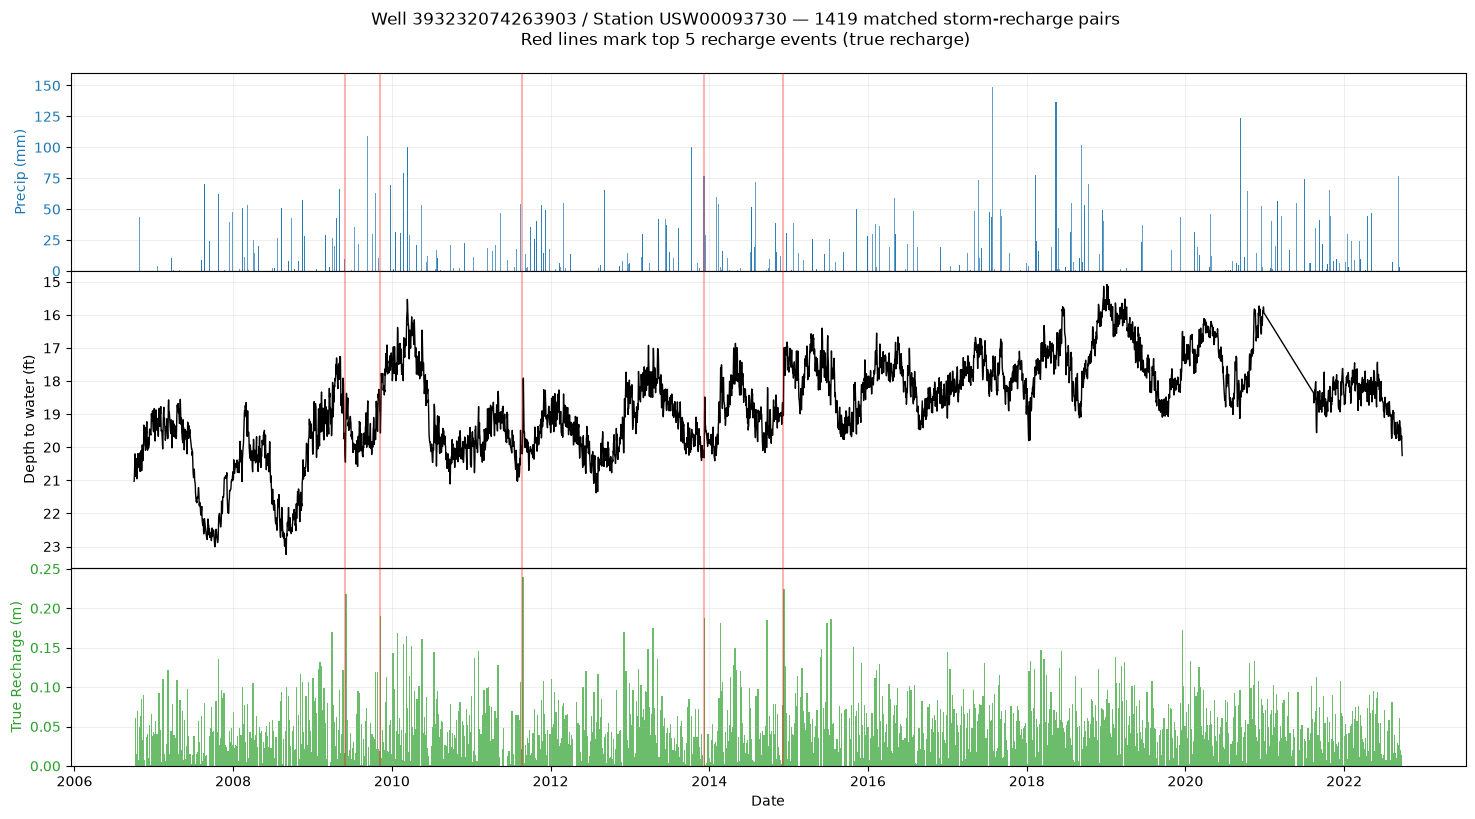

WELL 403455074514801  /  STATION USC00283029
Well: 403455074514801  |  Station: USC00283029

Recharge events (trough-based, true recharge): 2901 total
Matched to a preceding storm: 2800 of 2901 (96.5%)
Trimming to overlapping range: 1993-10-02 to 2022-09-26

Top 5 recharge events and their matched precipitation events:
     precip_start precip_end  total_precip_mm recharge_start recharge_end  \
2191   2015-05-28 2015-05-28              3.0     2015-05-31   2015-06-07   
1515   2008-08-30 2008-08-30             13.7     2008-09-02   2008-09-08   
2035   2013-11-22 2013-11-23              1.6     2013-11-24   2013-11-29   
2194   2015-06-09 2015-06-09             22.1     2015-06-13   2015-06-19   
2195   2015-06-15 2015-06-19             41.9     2015-06-19   2015-06-25   

      total_recharge_m  lag_days  
2191          0.238553       3.0  
1515          0.211267       3.0  
2035          0.210215       1.0  
2194          0.197685       4.0  
2195          0.167947       0.0  


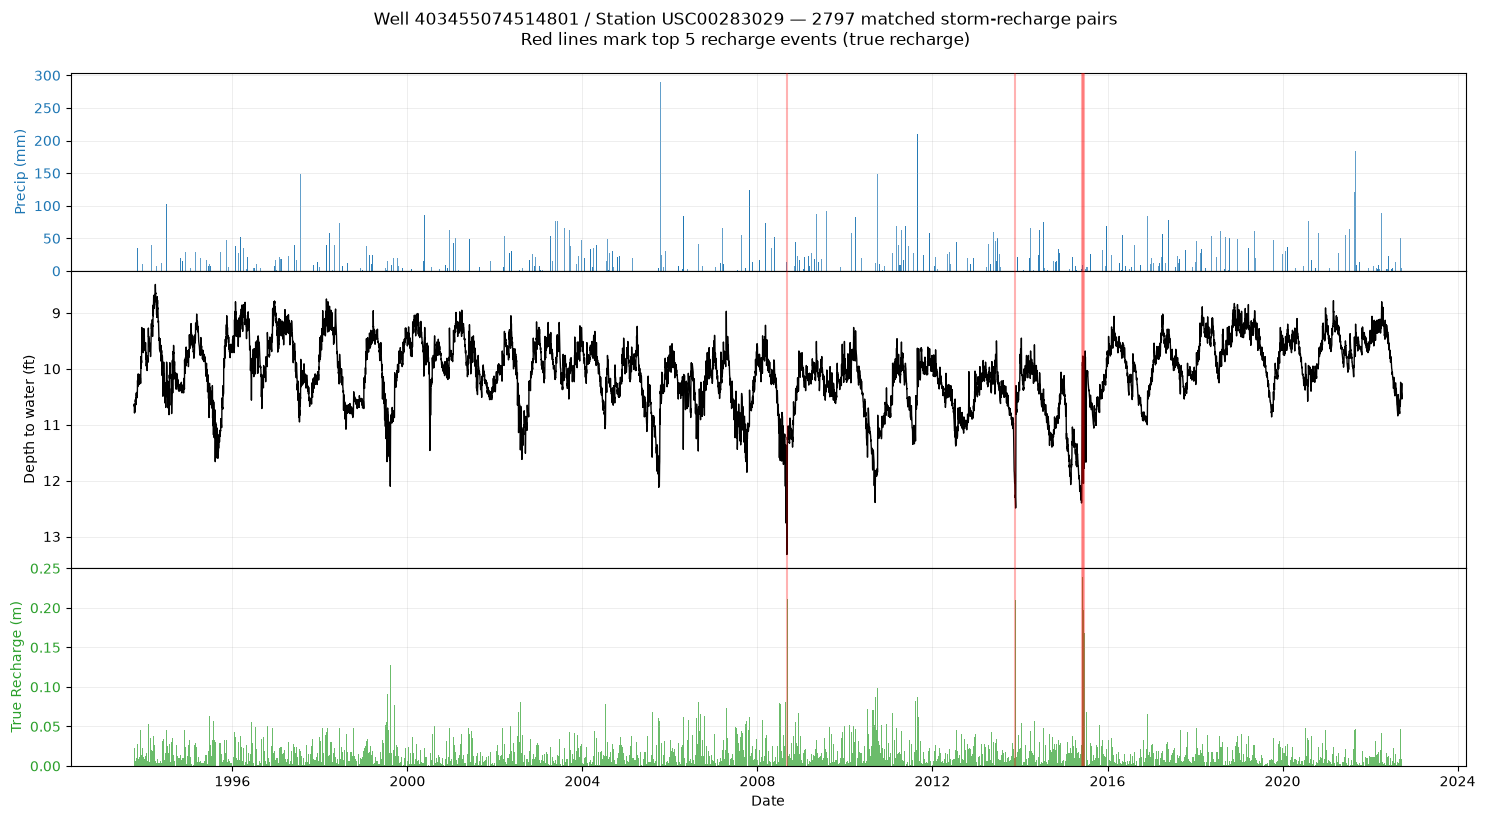

WELL 410207074270001  /  STATION USC00281582
Well: 410207074270001  |  Station: USC00281582

Recharge events (trough-based, true recharge): 2203 total
Matched to a preceding storm: 2052 of 2203 (93.1%)
Trimming to overlapping range: 1997-10-02 to 2022-09-23

Top 5 recharge events and their matched precipitation events:
     precip_start precip_end  total_precip_mm recharge_start recharge_end  \
1170   2011-08-22 2011-08-22             20.3     2011-08-23   2011-09-01   
1056   2010-03-03 2010-03-04              5.1     2010-03-11   2010-03-18   
1171   2011-08-26 2011-08-26              8.1     2011-09-01   2011-09-15   
1154   2011-05-04 2011-05-05             15.8     2011-05-10   2011-05-21   
793    2007-04-12 2007-04-13             26.2     2007-04-14   2007-04-21   

      total_recharge_m  lag_days  
1170          0.193328       1.0  
1056          0.178658       7.0  
1171          0.159166       6.0  
1154          0.145538       5.0  
793           0.144028       1.0  


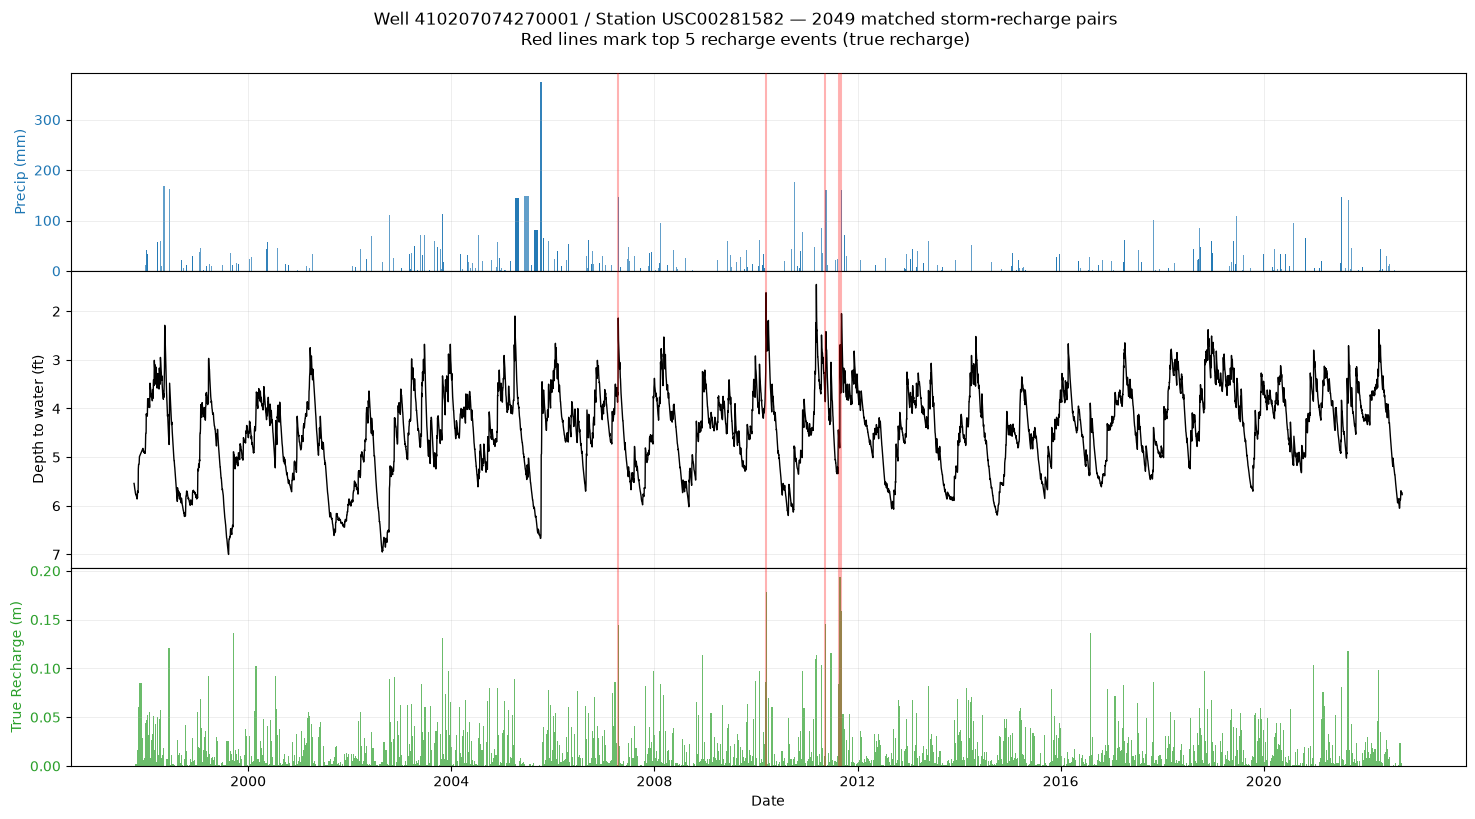

WELL 430146078101301  /  STATION USC00300443
Well: 430146078101301  |  Station: USC00300443

Recharge events (trough-based, true recharge): 447 total
Matched to a preceding storm: 436 of 447 (97.5%)
Trimming to overlapping range: 2015-10-02 to 2022-09-22

Top 5 recharge events and their matched precipitation events:
    precip_start precip_end  total_precip_mm recharge_start recharge_end  \
405   2022-02-10 2022-02-10              1.0     2022-02-15   2022-02-20   
87    2016-10-17 2016-10-17              3.0     2016-10-19   2016-10-26   
341   2021-02-22 2021-02-23              2.8     2021-02-27   2021-03-14   
366   2021-07-14 2021-07-14              9.1     2021-07-16   2021-07-30   
156   2018-01-05 2018-01-06              1.3     2018-01-09   2018-01-18   

     total_recharge_m  lag_days  
405          0.234081       5.0  
87           0.210197       2.0  
341          0.198707       4.0  
366          0.190243       2.0  
156          0.183328       3.0  


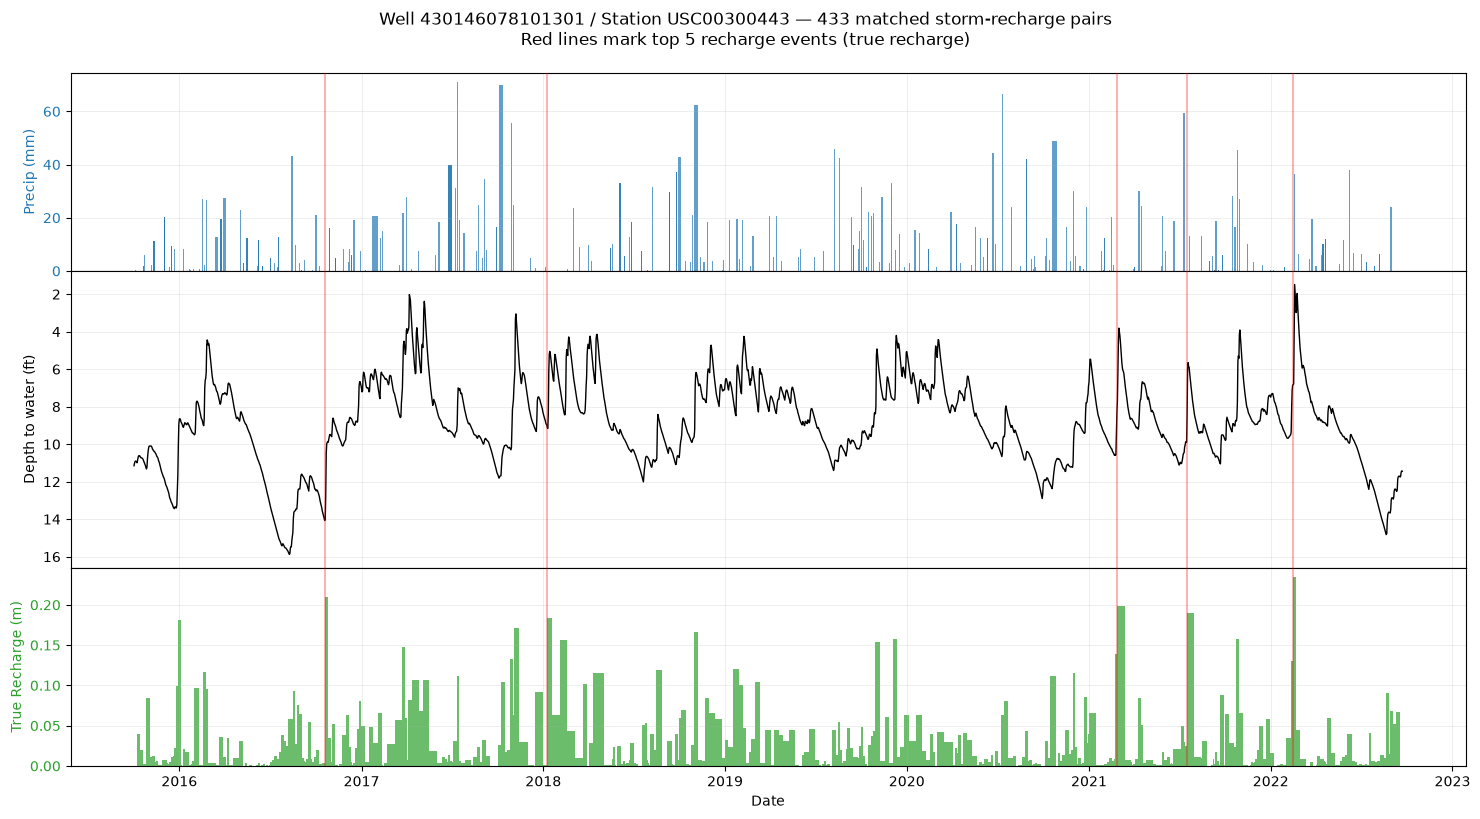


Completed 4 wells.


In [173]:
remaining_wells = sites_filtered[sites_filtered["nearest_station_id"].isin(henny_stations)]

henny_wells_to_run = remaining_wells[remaining_wells["usgs_id"].astype(str) != "402750078452201"]

henny_results = {}

for _, row in henny_wells_to_run.iterrows():
    usgs_id = str(row["usgs_id"])
    station_id = row["nearest_station_id"]

    print("=" * 70)
    print(f"WELL {usgs_id}  /  STATION {station_id}")
    print("=" * 70)

    recharge_path = os.path.join(recharge_dir, f"{usgs_id}.csv")
    if not os.path.exists(recharge_path):
        print(f"No recharge file for {usgs_id}. Skipping.\n")
        continue

    well = load_well(usgs_id, station_id, recharge_dir)

    matched_table_this = full_table(well["precip"], well["recharge"], well["well_id"], well["station_id"])
    timeseries_stacked(matched_table_this, well)

    henny_results[usgs_id] = {
        "matched_table": matched_table_this,
        "well": well,
    }

print(f"\nCompleted {len(henny_results)} wells.")

#### Check the record length of the five Henny wells alone. This function was made before the function that checks all the wells earlier on in the notebook. 

In [174]:
def check_length_for_wells(wells_df, recharge_dir):
    rows = []
    for _, row in wells_df.iterrows():
        well_id = str(row["usgs_id"])
        station_id = row["nearest_station_id"]

        print(f"Checking well {well_id} / station {station_id}...")

        try:
            precip = station_data(station_id, elements=("PRCP",))
            precip = precip[precip["element"] == "PRCP"]
            if len(precip) > 0:
                station_start = precip["date"].min()
                station_end = precip["date"].max()
                station_years = (station_end - station_start).days / 365.25
            else:
                station_start = station_end = None
                station_years = 0
        except Exception as e:
            print(f"  Error pulling station data: {e}")
            station_start = station_end = None
            station_years = 0

        recharge_path = os.path.join(recharge_dir, f"{well_id}.csv")
        if os.path.exists(recharge_path):
            recharge = pd.read_csv(recharge_path)
            recharge["Date"] = pd.to_datetime(recharge["Date"])
            recharge_start = recharge["Date"].min()
            recharge_end = recharge["Date"].max()
            recharge_years = (recharge_end - recharge_start).days / 365.25
        else:
            recharge_start = recharge_end = None
            recharge_years = 0

        rows.append({
            "usgs_id": well_id, "station_id": station_id,
            "station_start": station_start, "station_end": station_end,
            "station_years": round(station_years, 1),
            "recharge_start": recharge_start, "recharge_end": recharge_end,
            "recharge_years": round(recharge_years, 1),
        })

    return pd.DataFrame(rows)

In [175]:
henny_length_summary = check_length_for_wells(
    henny_five_wells, r"C:\Users\romin\OneDrive\Groundwater\RpSy Data"
)
print(henny_length_summary)

Checking well 393232074263903 / station USW00093730...
Checking well 402750078452201 / station USC00362470...
Checking well 403455074514801 / station USC00283029...
Checking well 410207074270001 / station USC00281582...
Checking well 430146078101301 / station USC00300443...
           usgs_id   station_id station_start station_end  station_years  \
0  393232074263903  USW00093730    1958-06-16  2026-08-09           68.1   
1  402750078452201  USC00362470    1964-02-01  2026-08-10           62.5   
2  403455074514801  USC00283029    1898-03-01  2026-08-10          128.4   
3  410207074270001  USC00281582    1893-04-01  2026-08-09          133.4   
4  430146078101301  USC00300443    1911-06-10  2026-07-24          115.1   

  recharge_start recharge_end  recharge_years  
0     2006-10-02   2022-09-30            16.0  
1     2008-10-02   2022-09-30            14.0  
2     1993-10-02   2022-09-30            29.0  
3     1997-10-02   2022-09-30            25.0  
4     2015-10-02   2022-09-3

#### Create plot to visualize the trends in recharge and precipiation for the five wells. 

Well: 393232074263903  |  Station: USW00093730
Precip trend: +4.40 mm/year  (over 67 full years)
True recharge trend: +0.06060 m/year  (over 15 full years)



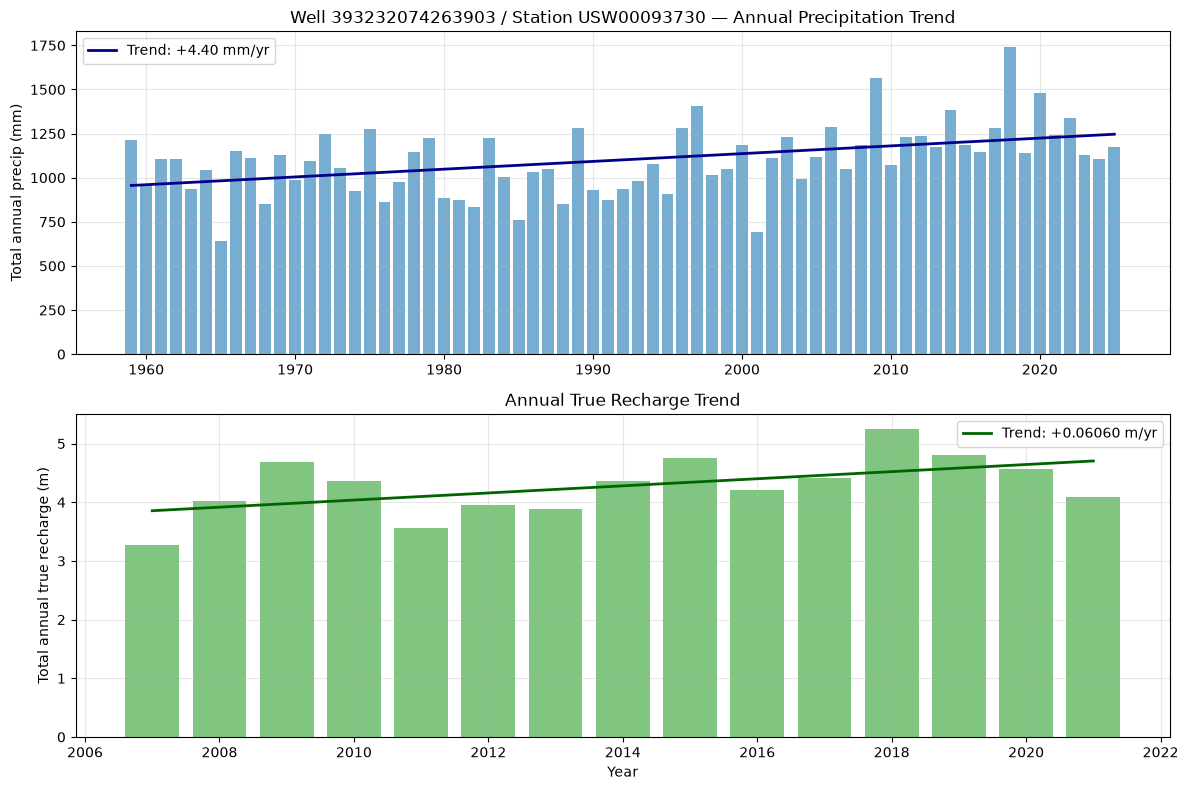

Well: 402750078452201  |  Station: USC00362470
Precip trend: +0.65 mm/year  (over 62 full years)
True recharge trend: -0.00300 m/year  (over 13 full years)



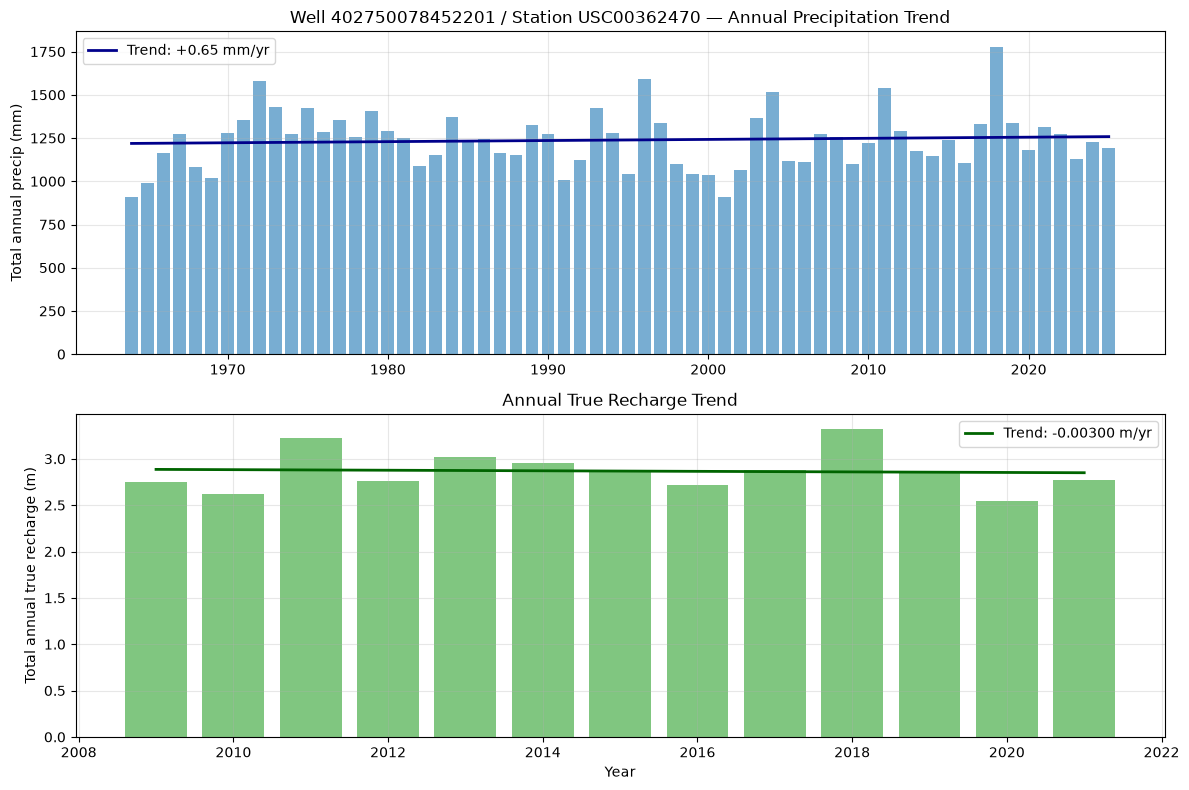

Well: 403455074514801  |  Station: USC00283029
Precip trend: +1.78 mm/year  (over 125 full years)
True recharge trend: -0.01234 m/year  (over 28 full years)



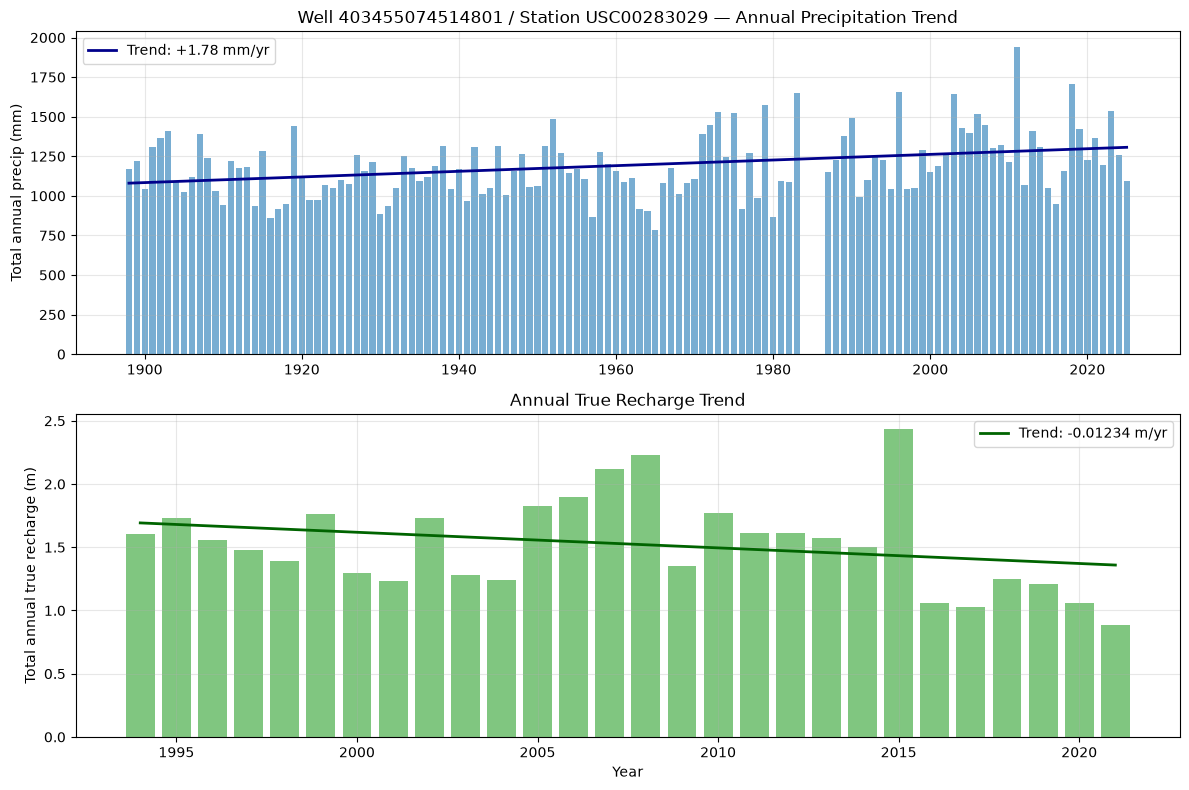

Well: 410207074270001  |  Station: USC00281582
Precip trend: +4.25 mm/year  (over 123 full years)
True recharge trend: +0.01056 m/year  (over 24 full years)



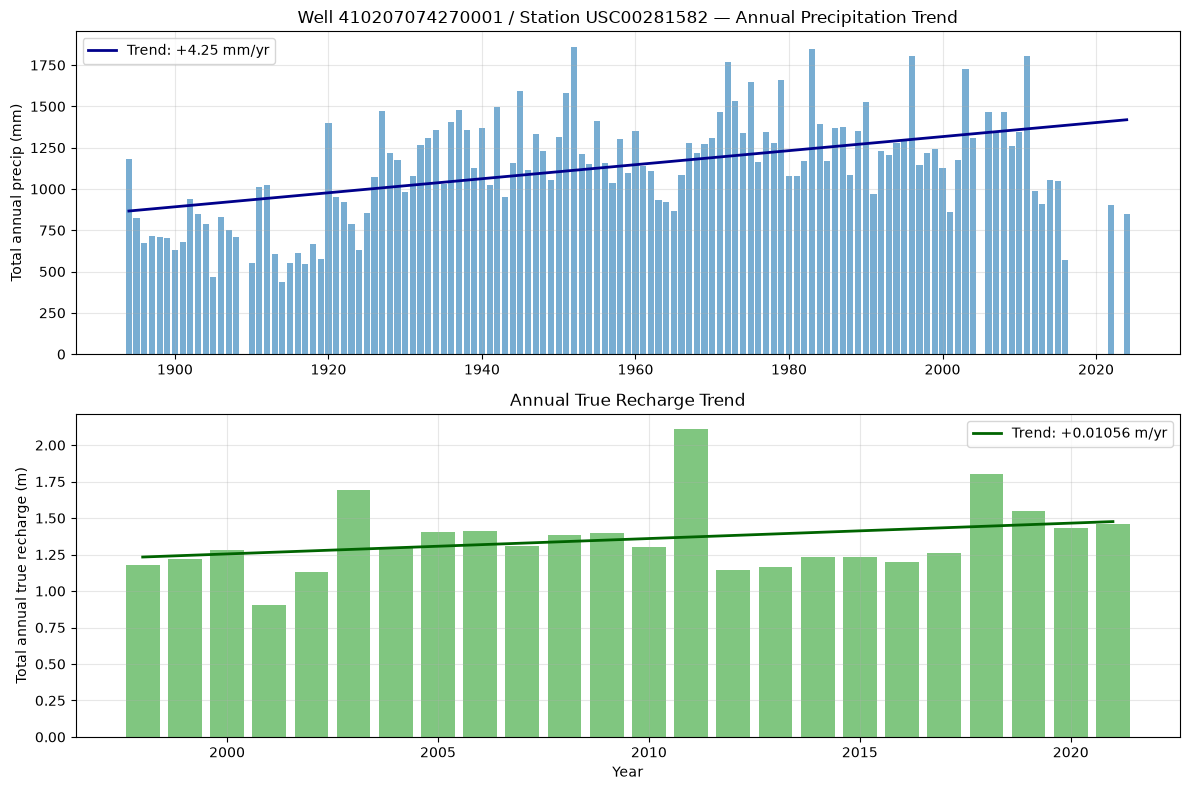

Well: 430146078101301  |  Station: USC00300443
Precip trend: +1.57 mm/year  (over 93 full years)
True recharge trend: -0.03940 m/year  (over 6 full years)



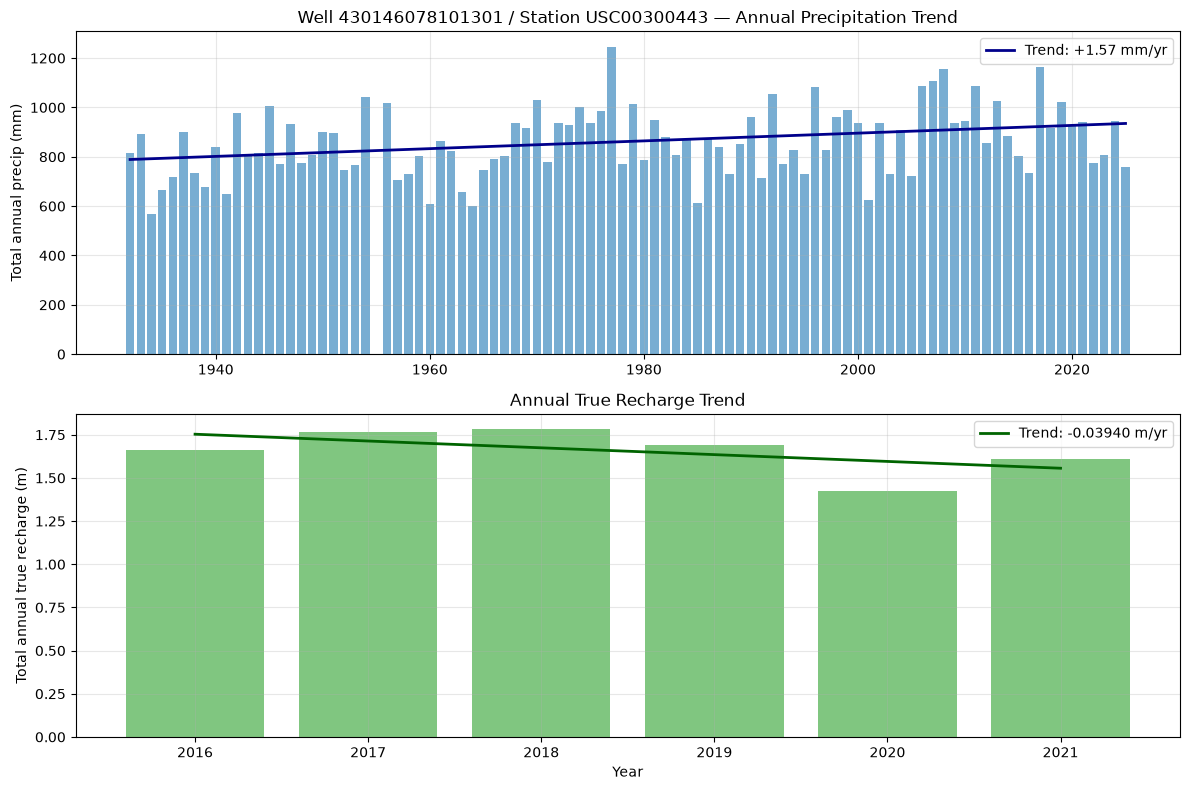

In [176]:
def analyze_trends(well):
    """
    Computes yearly total precip and yearly total true recharge,
    fits a linear trend to each, and plots both.
    """
    well_id = well["well_id"]
    station_id = well["station_id"]

    precip = well["precip"].copy()
    precip["year"] = precip["date"].dt.year

    recharge = well["recharge"].copy()
    recharge["Date"] = pd.to_datetime(recharge["Date"])
    recharge["year"] = recharge["Date"].dt.year

    sy = SY_BY_WELL.get(well_id)
    if sy is not None:
        sy_val = sy["sy_mid"] if isinstance(sy, dict) else sy
        recharge["true_recharge_m"] = recharge["RpSy (m)"] * sy_val
    else:
        recharge["true_recharge_m"] = recharge["RpSy (m)"]

    # Only keep full years (≥300 days of data)
    precip_counts = precip.groupby("year").size()
    recharge_counts = recharge.groupby("year").size()
    full_precip_years = precip_counts[precip_counts >= 300].index
    full_recharge_years = recharge_counts[recharge_counts >= 300].index

    yearly_precip = precip[precip["year"].isin(full_precip_years)].groupby("year")["precip_mm"].sum().reset_index()
    yearly_recharge = recharge[recharge["year"].isin(full_recharge_years)].groupby("year")["true_recharge_m"].sum().reset_index()

    if len(yearly_precip) < 2 or len(yearly_recharge) < 2:
        print(f"Well {well_id}: not enough full years of data to fit a trend. Skipping.\n")
        return None

    precip_slope, precip_intercept = np.polyfit(yearly_precip["year"], yearly_precip["precip_mm"], 1)
    recharge_slope, recharge_intercept = np.polyfit(yearly_recharge["year"], yearly_recharge["true_recharge_m"], 1)

    print(f"Well: {well_id}  |  Station: {station_id}")
    print(f"Precip trend: {precip_slope:+.2f} mm/year  (over {len(yearly_precip)} full years)")
    print(f"True recharge trend: {recharge_slope:+.5f} m/year  (over {len(yearly_recharge)} full years)\n")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    ax1.bar(yearly_precip["year"], yearly_precip["precip_mm"], color="tab:blue", alpha=0.6)
    ax1.plot(yearly_precip["year"], precip_slope * yearly_precip["year"] + precip_intercept,
              color="darkblue", linewidth=2, label=f"Trend: {precip_slope:+.2f} mm/yr")
    ax1.set_ylabel("Total annual precip (mm)")
    ax1.set_title(f"Well {well_id} / Station {station_id} — Annual Precipitation Trend")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.bar(yearly_recharge["year"], yearly_recharge["true_recharge_m"], color="tab:green", alpha=0.6)
    ax2.plot(yearly_recharge["year"], recharge_slope * yearly_recharge["year"] + recharge_intercept,
              color="darkgreen", linewidth=2, label=f"Trend: {recharge_slope:+.5f} m/yr")
    ax2.set_ylabel("Total annual true recharge (m)")
    ax2.set_xlabel("Year")
    ax2.set_title("Annual True Recharge Trend")
    ax2.legend()
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return {"yearly_precip": yearly_precip, "yearly_recharge": yearly_recharge,
            "precip_slope": precip_slope, "recharge_slope": recharge_slope}


def analyze_all_henny_wells(wells_df, recharge_dir):
    """
    Loads each well via load_well and runs analyze_trends on it.
    """
    results = {}
    for _, row in wells_df.iterrows():
        usgs_id = str(row["usgs_id"])
        station_id = row["nearest_station_id"]

        recharge_path = os.path.join(recharge_dir, f"{usgs_id}.csv")
        if not os.path.exists(recharge_path):
            print(f"No recharge file for {usgs_id}. Skipping.\n")
            continue

        well = load_well(usgs_id, station_id, recharge_dir)
        result = analyze_trends(well)
        if result is not None:
            results[usgs_id] = result

    return results


all_trend_results = analyze_all_henny_wells(remaining_wells, recharge_dir)

#### Begin calculating the storm statistics as based off of the Henny covarients. 

## Storm & Recharge Covariates — Definitions

| Variable | Full Name | Formula | Units |
|---|---|---|---|
| **DUR** | Duration | Days between when 5% and 95% of the storm's cumulative precipitation fell | days |
| **MAG** | Magnitude | 0.90 × total precipitation in the storm window (matching window of DUR)| mm |
| **AVG** | Average Rate | MAG / DUR | mm/day |
| **DEP** | Depth to Water Table | Most recent groundwater head reading on/before the storm start, converted from feet to meters (depth_ft × 0.3048) | m |
| **RECH** | Recharge | True recharge from the matched trough-to-trough recharge event, RpSy × Sy | m |
| **RPR** | Recharge-to-Precipitation Ratio | (RECH × 1000) / MAG | unitless |
| **INT** | Weighted Hourly Intensity | *need help yet!!!!!* | — |


#### Duration refers to the concentration of rain over how many days not how many calendar days as specified by tashie. 

In [177]:
def compute_storm_stats(precip_daily_df, storm_start, storm_end, date_col="date", precip_col="precip_mm"):
    """
    Computes DUR, MAG, AVG for one storm event.
    DUR: days from 5% to 95% of cumulative precip in the window
    MAG: 90% of total precip in the window
    AVG: MAG / DUR
    """
    window = precip_daily_df[
        (precip_daily_df[date_col] >= storm_start) & (precip_daily_df[date_col] <= storm_end)
    ].sort_values(date_col).copy()

    total = window[precip_col].sum()
    if total == 0:
        return {"DUR": None, "MAG": None, "AVG": None}

    window["cm_precip"] = window[precip_col].cumsum()
    window["cm_fraction"] = window["cm_precip"] / total

    start_5pct = window[window["cm_fraction"] >= 0.05][date_col].iloc[0]
    end_95pct = window[window["cm_fraction"] >= 0.95][date_col].iloc[0]
    dur = max((end_95pct - start_5pct).days, 1)

    mag = total * 0.90
    avg = mag / dur

    return {"DUR": dur, "MAG": mag, "AVG": avg}

In [178]:
def compute_rcr(precip_daily_df, storm_start, date_col="date", precip_col="precip_mm", max_lookback=60):
    """
    RCR: number of consecutive days before the storm with < 1cm (10mm)
    of precip in any 24hr period — i.e., how long since the last
    meaningful rain before this storm started.
    """
    lookback_window = precip_daily_df[
        (precip_daily_df[date_col] < storm_start) &
        (precip_daily_df[date_col] >= storm_start - pd.Timedelta(days=max_lookback))
    ].sort_values(date_col, ascending=False)

    rcr = 0
    for _, row in lookback_window.iterrows():
        if row[precip_col] < 10:  # less than 1cm
            rcr += 1
        else:
            break
    return rcr

In [179]:
def compute_dep(gw_head_df, storm_start, date_col="date", depth_col="depth_to_water_ft"):
    """DEP: depth to water table (in meters) at the start of the recharge event."""
    match = gw_head_df[gw_head_df[date_col] <= storm_start].sort_values(date_col)
    if len(match) == 0:
        return None
    depth_ft = match.iloc[-1][depth_col]
    return depth_ft * 0.3048  # convert feet to meters


def compute_rpr(recharge_value_m, mag_mm):
    """
    RPR: ratio of recharge to precipitation magnitude, both converted to mm.
    """
    if recharge_value_m is None or mag_mm is None or mag_mm == 0:
        return None
    recharge_value_mm = recharge_value_m * 1000
    return recharge_value_mm / mag_mm

In [180]:
def enrich_well_table(matched_table, precip_daily, gw_head_df, well_id, recharge_col="total_recharge_m_recharge"):
    """
    Runs DUR, MAG, AVG, RPR, and DEP for every storm in one well's
    matched table, and returns the table with those columns added.

    For wells with a low/mid/high Sy range (like Glenshaw), pass the
    matching recharge column name explicitly (e.g. "total_recharge_m_recharge_sy_mid").
    """
    table = matched_table.copy()

    dur_list, mag_list, avg_list, rpr_list, dep_list = [], [], [], [], []

    for _, row in table.iterrows():
        stats = compute_storm_stats(precip_daily, row["precip_start"], row["precip_end"])
        dur_list.append(stats["DUR"])
        mag_list.append(stats["MAG"])
        avg_list.append(stats["AVG"])

        recharge_value = row.get(recharge_col)
        rpr_list.append(compute_rpr(recharge_value, stats["MAG"]))

        if gw_head_df is not None:
            dep_list.append(compute_dep(gw_head_df, row["precip_start"]))
        else:
            dep_list.append(None)

    table["DUR"] = dur_list
    table["MAG"] = mag_list
    table["AVG"] = avg_list
    table["RPR"] = rpr_list
    table["DEP"] = dep_list

    return table
    

In [181]:
test_well_id = "402750078452201"

well = load_well(test_well_id, henny_wells_info[test_well_id], recharge_dir)

test_table = full_table(
    well["precip"], well["recharge"], well["well_id"], well["station_id"]
)

enriched = enrich_well_table(
    test_table, well["precip"], well["head"], well["well_id"],
    recharge_col="total_recharge_m"
)


Well: 402750078452201  |  Station: USC00362470

Recharge events (trough-based, true recharge): 1259 total
Matched to a preceding storm: 1241 of 1259 (98.6%)


#### Following Tashie and dropping any storm with 1cm< of precipitation and RPR outliers. Struggling with RPR a bit due to some recharge events matching to the same storm which messes up the rpr values etc. In the following code I attempt to deal with the issue.   

In [187]:
enriched_filtered = enriched[
    (enriched["MAG"] >= 10) &
    (enriched["RPR"] > 0) &
    (enriched["RPR"] < 5)
].copy()

print(f"Before filtering: {len(enriched)} storms")
print(f"After filtering: {len(enriched_filtered)} storms")

Before filtering: 447 storms
After filtering: 156 storms


In [188]:
filtered = enriched[enriched["MAG"] >= 10].copy()
filtered = filtered[(filtered["RPR"] > 0) & (filtered["RPR"] < 5)].copy()
print(f"Before filtering: {len(enriched)}")
print(f"After filtering: {len(filtered)}")
print(filtered[["precip_start", "precip_end", "total_precip_mm", "DUR", "MAG", "RPR", "DEP"]].head(10))

# One row per recharge event — since recharge_start/recharge_end uniquely
# identify each recharge episode, keep only the best-matching storm per one
deduped = filtered.sort_values("lag_days").drop_duplicates(
    subset=["recharge_start", "recharge_end"], keep="first"
)


Before filtering: 447
After filtering: 156
   precip_start precip_end  total_precip_mm  DUR    MAG       RPR       DEP
0    2015-09-28 2015-10-01             62.6  2.0  56.34  0.115090       NaN
8    2015-11-10 2015-11-13             11.3  3.0  10.17  0.062509  3.151632
9    2015-11-10 2015-11-13             11.3  3.0  10.17  0.083906  3.151632
13   2015-12-02 2015-12-04             20.3  1.0  18.27  0.052278  3.617976
14   2015-12-02 2015-12-04             20.3  1.0  18.27  0.030901  3.617976
15   2015-12-02 2015-12-04             20.3  1.0  18.27  0.014081  3.617976
16   2015-12-02 2015-12-04             20.3  1.0  18.27  0.037701  3.617976
21   2015-12-27 2015-12-27             16.5  1.0  14.85  1.704974  4.029456
22   2015-12-29 2015-12-30             15.5  1.0  13.95  0.007024  3.550920
23   2015-12-29 2015-12-30             15.5  1.0  13.95  0.003449  3.550920


In [184]:
def combine_recharge_pulses(enriched_df, recharge_col="total_recharge_m"):
    """
    Sums multiple recharge events matched to the same storm into one
    row per storm, then computes RPR from the combined total.
    """
    combined = enriched_df.groupby(
        ["precip_start", "precip_end", "total_precip_mm", "DUR", "MAG", "AVG"],
        as_index=False
    ).agg(
        total_recharge_m=(recharge_col, "sum"),
        n_pulses=(recharge_col, "count"),
        DEP=("DEP", "first"),
    )

    combined["RPR"] = combined.apply(
        lambda row: compute_rpr(row["total_recharge_m"], row["MAG"]), axis=1
    )

    return combined

#### Create csv files with the covarients added. 

In [185]:
final_well_tables = {}

for well_id, station_id in henny_wells_info.items():
    print("=" * 60)
    print(f"WELL {well_id}  /  STATION {station_id}")
    print("=" * 60)

    table = all_matched_tables_recharge[well_id]

    precip_daily = station_data_int(station_id, elements=("PRCP",))
    precip_daily = precip_daily[precip_daily["element"] == "PRCP"][["date", "value"]].rename(columns={"value": "precip_mm"})

    gw_head = get_usgs_groundwater(
        well_id,
        start_date=table["recharge_start"].min().strftime("%Y-%m-%d"),
        end_date="2024-01-01"
    )
    gw_head = gw_head.rename(columns={"datetime": "date"}) if gw_head is not None and not gw_head.empty else None

    # Determine the correct recharge column name for this well
    recharge_col = "total_recharge_m_recharge"
    if recharge_col not in table.columns:
        # fall back for any well with a different naming pattern (e.g. Sy range wells)
        candidates = [c for c in table.columns if c.startswith("total_recharge_m_recharge")]
        recharge_col = candidates[0] if candidates else "total_recharge_m"

    enriched = enrich_well_table(table, precip_daily, gw_head, well_id, recharge_col=recharge_col)

    # Filter: minimum storm magnitude, remove implausible RPR outliers
    filtered = enriched[enriched["MAG"] >= 10].copy()
    filtered = filtered[(filtered["RPR"] > 0) & (filtered["RPR"] < 5)].copy()

    # Combine multiple recharge pulses tied to the same storm into one row
    combined = combine_recharge_pulses(filtered, recharge_col=recharge_col)
    combined = combined.rename(columns={"total_recharge_m": "RECH"})  # label recharge as its own variable

    print(f"Total storms: {len(enriched)}  ->  Filtered: {len(filtered)}  ->  Combined (final): {len(combined)}")

    out_path = f"{well_id}_covariates.csv"
    combined.to_csv(out_path, index=False)
    print(f"Saved {out_path}\n")

    final_well_tables[well_id] = combined

print(f"\nCompleted: {len(final_well_tables)} of {len(henny_wells_info)} wells")

WELL 393232074263903  /  STATION USW00093730
Total storms: 1469  ->  Filtered: 713  ->  Combined (final): 454
Saved 393232074263903_covariates.csv

WELL 402750078452201  /  STATION USC00362470
Total storms: 1259  ->  Filtered: 651  ->  Combined (final): 437
Saved 402750078452201_covariates.csv

WELL 403455074514801  /  STATION USC00283029
Total storms: 2901  ->  Filtered: 1431  ->  Combined (final): 933
Saved 403455074514801_covariates.csv

WELL 410207074270001  /  STATION USC00281582
Total storms: 2203  ->  Filtered: 987  ->  Combined (final): 630
Saved 410207074270001_covariates.csv

WELL 430146078101301  /  STATION USC00300443
Total storms: 447  ->  Filtered: 156  ->  Combined (final): 127
Saved 430146078101301_covariates.csv


Completed: 5 of 5 wells


#### Plot the various relationships. 

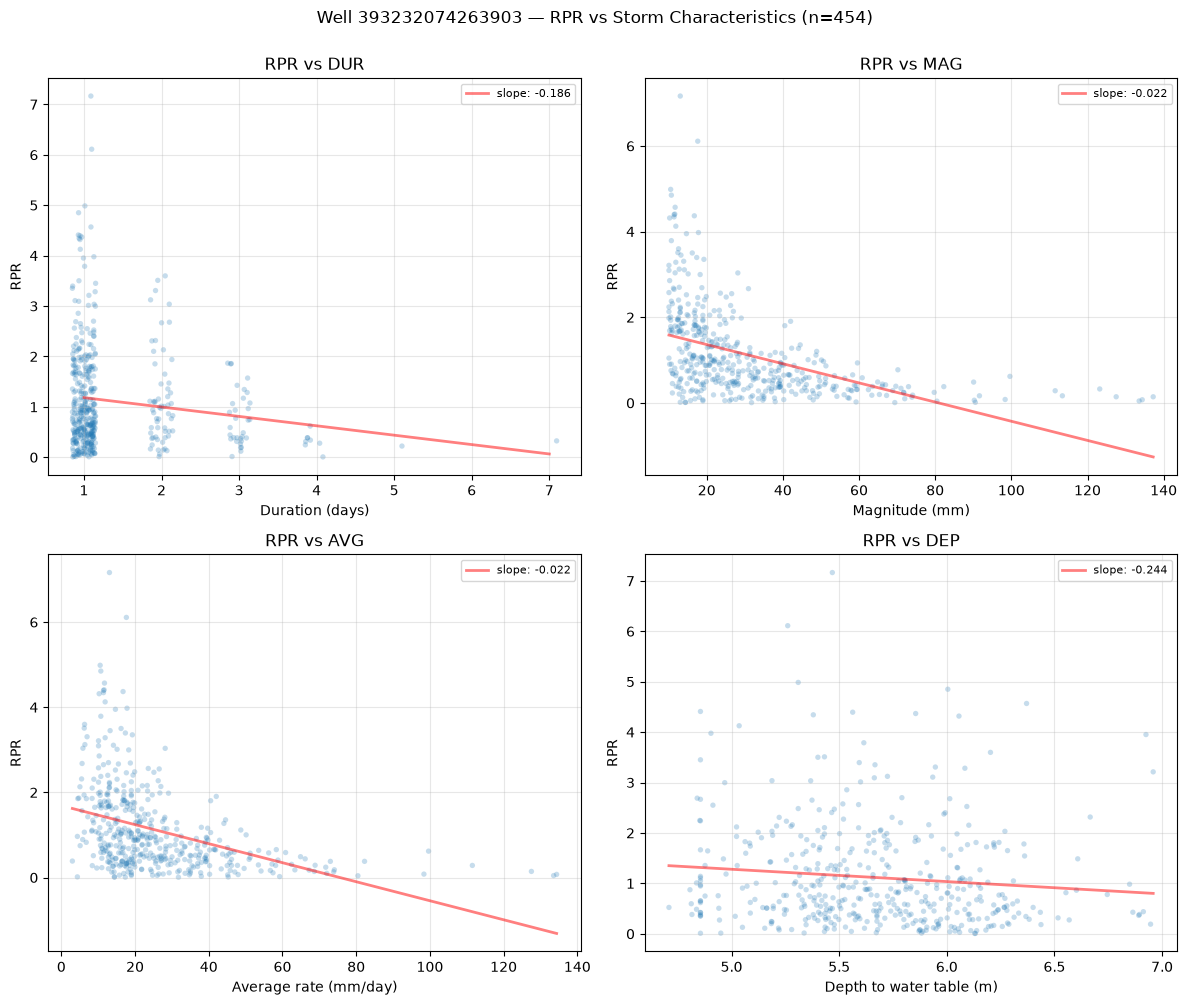

In [186]:
def plot_rpr_relationships(well_table, well_id):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    pairs = [
        ("DUR", "Duration (days)"),
        ("MAG", "Magnitude (mm)"),
        ("AVG", "Average rate (mm/day)"),
        ("DEP", "Depth to water table (m)"),
    ]

    for ax, (col, label) in zip(axes.flat, pairs):
        data = well_table.dropna(subset=[col, "RPR"]).copy()

        x = data[col].values
        y = data["RPR"].values

        if col == "DUR":
            jitter = np.random.uniform(-0.15, 0.15, size=len(x))
            x_plot = x + jitter
        else:
            x_plot = x

        ax.scatter(x_plot, y, alpha=0.25, s=15, color="tab:blue", edgecolor="none")

        if len(x) > 2:
            coeffs = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = coeffs[0] * x_line + coeffs[1]
            ax.plot(x_line, y_line, color="red", linewidth=2, alpha=0.5, label=f"slope: {coeffs[0]:.3f}")
            ax.legend(fontsize=8)

        ax.set_xlabel(label)
        ax.set_ylabel("RPR")
        ax.set_title(f"RPR vs {col}")
        ax.grid(alpha=0.3)

    fig.suptitle(f"Well {well_id} — RPR vs Storm Characteristics (n={len(well_table)})", y=1.00)
    fig.tight_layout()
    plt.show()


test_well_id = list(final_well_tables.keys())[0]
plot_rpr_relationships(final_well_tables[test_well_id], test_well_id)